Le rôle de ce notebook est de générer des données de fraudes à partir du DAG causal généré

In [1]:
import pandas as pd
data = pd.read_csv("../Fraud Detection Dataset.csv")
data.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [2]:
# 1. Stats globales
stats_globales = data.describe(include='all').to_dict()

# 2. Corrélations numériques
correlations = data.select_dtypes(include='number').corr().to_dict()

# 3. Distribution des variables catégorielles
cat_cols = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']
distrib_cat = {col: data[col].value_counts(normalize=True).to_dict() for col in cat_cols}

# 4. Stats par classe (fraude vs non-fraude)
stats_par_classe = data.groupby('Fraudulent').describe().to_dict()

# Envoyer ce résumé au LLM au lieu du dataset brut
resume = {
    "stats_globales": stats_globales,
    "correlations": correlations,
    "distribution_categorielle": distrib_cat,
    "stats_par_classe": stats_par_classe
}

In [3]:
# Moyennes des variables numériques par classe (fraude / non-fraude)
moyennes_par_classe = (
    data.select_dtypes(include='number')
    .groupby(data['Fraudulent'])
    .mean()
    .to_dict()
)

# Ajout au résumé
print(moyennes_par_classe)

{'User_ID': {0: 3002.9993194473086, 1: 3045.8892430278884}, 'Transaction_Amount': {0: 2989.9313086018005, 1: 3118.3672452830187}, 'Time_of_Transaction': {0: 11.477339815940267, 1: 11.702861952861953}, 'Previous_Fraudulent_Transactions': {0: 1.9953598680140234, 1: 2.002788844621514}, 'Account_Age': {0: 59.98537842854197, 1: 60.971314741035854}, 'Number_of_Transactions_Last_24H': {0: 7.499133842029284, 1: 7.427091633466135}, 'Fraudulent': {0: 0.0, 1: 1.0}}


In [4]:
# Statistiques numériques réduites
stats_reduites = (
    data.describe()
    .loc[['mean', 'std', 'min', 'max']]
    .to_dict()
)

# Ajout dans le résumé
resume = {
    "stats_globales": stats_globales,
    "correlations": correlations,
    "distribution_categorielle": distrib_cat,
    "stats_par_classe": stats_par_classe,
    "stats_reduites": stats_reduites
}

In [5]:
# VERIFIER QUE LE LLM NE GENERE PAS DES TRUCS INCONNUS 
import os
import json
import re
import time
import urllib3
import requests

# ─────────────────────────────────────────────
# 1. CONFIGURATION API
# ─────────────────────────────────────────────

OLLAMA_API_URL = "https://ollama-api.lab.groupe-genes.fr/api/generate"
MODEL_NAME = "mistral"

SKIP_SSL_VERIFY = True
MAX_RETRIES_LOAD = 2
RETRY_DELAY_SECONDS = 2

if SKIP_SSL_VERIFY:
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ─────────────────────────────────────────────
# 2. CHARGEMENT ET FORMATAGE DU GRAPHE CAUSAL
# ─────────────────────────────────────────────

def _normalize_edges(edges_raw: list) -> list:
    FROM_KEYS = ["from", "de", "source", "cause",  "parent", "src", "origine"]
    TO_KEYS   = ["to",   "vers", "target", "cible", "effet",  "child", "dst"]
    JUST_KEYS = ["justification", "justification_experte", "raison", "label", "reason"]

    normalized = []
    for e in edges_raw:
        if isinstance(e, dict):
            src = next((e[k] for k in FROM_KEYS if k in e), None)
            tgt = next((e[k] for k in TO_KEYS   if k in e), None)
            jst = next((e[k] for k in JUST_KEYS if k in e), "")
            if src and tgt:
                normalized.append({
                    "from":          src,
                    "to":            tgt,
                    "justification": jst,
                    # on conserve aussi les méta-données de confiance si présentes
                    "confiance":     e.get("confiance_pct", e.get("confiance", ""))
                })
        elif isinstance(e, (list, tuple)) and len(e) >= 2:
            normalized.append({"from": e[0], "to": e[1], "justification": ""})

    return normalized

def load_causal_graph(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    NODE_KEYS = ["nodes", "noeuds", "nœuds", "vertices", "variables", "features", "columns"]
    EDGE_KEYS = ["edges", "liens", "links", "causal_links", "arcs", "arrows", "relations"]

    node_key = next((k for k in NODE_KEYS if k in raw), None)
    edge_key  = next((k for k in EDGE_KEYS if k in raw), None)

    if node_key and edge_key:
        edges = _normalize_edges(raw[edge_key])
        return {
            "nodes":      raw[node_key],
            "edges":      edges,
            "commentaire": raw.get("commentaire_expert", "")
        }

    raise ValueError(
        f"Format non reconnu. Clés trouvées : {list(raw.keys())}"
    )


def format_graph_for_prompt(graph: dict) -> str:
    lines = ["Variables du dataset :", ""]
    for node in graph["nodes"]:
        lines.append(f"  - {node}")

    lines += ["", "Relations causales (A → B : justification [confiance]) :", ""]
    for edge in graph["edges"]:
        confiance = f" [confiance : {edge['confiance']}]" if edge.get("confiance") else ""
        lines.append(
            f"  - {edge['from']} → {edge['to']} : {edge['justification']}{confiance}"
        )

    # Nœuds puits = variable(s) cible(s)
    sources = {e["from"] for e in graph["edges"]}
    targets = {e["to"]   for e in graph["edges"]}
    sink_nodes = targets - sources
    if sink_nodes:
        lines += ["", f"Variable(s) cible(s) : {', '.join(sink_nodes)}"]

    # Commentaire expert si présent
    if graph.get("commentaire"):
        lines += ["", f"Contexte expert : {graph['commentaire'][:300]}"]

    return "\n".join(lines)


def get_feature_list(graph: dict) -> list[str]:
    """Retourne la liste des variables hors cibles (features à générer)."""
    targets = {e["to"] for e in graph["edges"]} - {e["from"] for e in graph["edges"]}
    return [n for n in graph["nodes"] if n not in targets]


# ─────────────────────────────────────────────
# 3. CONSTRUCTION DU PROMPT
# ─────────────────────────────────────────────

def build_prompt(graph: dict, n_samples: int = 5) -> str:
    graph_description = format_graph_for_prompt(graph)

    return f"""
Tu es un expert en détection de fraude bancaire.

Le graphe causal suivant représente les relations causales entre les variables
du dataset de détection de fraude. Chaque flèche indique qu'une variable influence
directement une autre.

{graph_description}

Ta tâche est de GÉNÉRER des cas de fraude réalistes en respectant scrupuleusement
ces relations causales :
- Les valeurs générées doivent être cohérentes avec les dépendances causales décrites
- Chaque transaction doit contenir des signaux suspects typiques d'une fraude
- Respecte les chemins causaux (ex: si Previous_Fraudulent_Transactions est élevé,
  alors Number_of_Transactions_Last_24H et Transaction_Amount doivent l'être aussi)
- Raisonne étape par étape mais ne montre PAS ton raisonnement
- Réponds UNIQUEMENT avec un objet JSON valide, sans texte autour, sans markdown

Voici des exemples de transactions FRAUDULEUSES :

 	Transaction_ID 	User_ID 	Transaction_Amount 	Transaction_Type 	Time_of_Transaction 	Device_Used 	Location 	Previous_Fraudulent_Transactions 	Account_Age 	Number_of_Transactions_Last_24H 	Payment_Method 	Fraudulent
6 	T7 	4772 	544.81 	Bill Payment 	2.0 	Tablet 	Boston 	3 	6 	9 	UPI 	1
27 	T28 	3433 	4519.04 	Bill Payment 	13.0 	Tablet 	Boston 	0 	81 	10 	Credit Card 	1
43 	T44 	3047 	4413.05 	Bank Transfer 	21.0 	Desktop 	Boston 	4 	46 	11 	Credit Card 	1
68 	T69 	3363 	3517.65 	Bill Payment 	0.0 	Desktop 	Boston 	2 	29 	8 	UPI 	1
73 	T74 	4417 	1440.79 	Online Purchase 	15.0 	Tablet 	Miami 	2 	16 	1 	Net Ban

Les statistiques sur les transactions frauduleuses sont les suivantes : {stats_reduites}
Maintenant, génère {n_samples} nouvelles transactions frauduleuses réalistes.
Réponds avec un JSON valide contenant une clé "transactions" qui est une liste
de {n_samples} objets ayant exactement les mêmes champs que les exemples.
"""


# ─────────────────────────────────────────────
# 4. APPEL API OLLAMA AVEC RETRY
# ─────────────────────────────────────────────

def call_ollama(prompt: str) -> str | None:
    """Appelle l'API Ollama et retourne le texte généré."""
    payload = {
        "model": MODEL_NAME,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": 0.5,
            "num_predict": 20000,
        }
    }

    for attempt in range(1, MAX_RETRIES_LOAD + 1):
        try:
            response = requests.post(
                OLLAMA_API_URL,
                json=payload,
                verify=not SKIP_SSL_VERIFY,
                timeout=120
            )
            response.raise_for_status()
            return response.json().get("response", "")

        except requests.exceptions.HTTPError as e:
            if response.status_code in (503, 429):
                print(f"⏳ Modèle en chargement (HTTP {response.status_code}), "
                      f"nouvel essai dans {RETRY_DELAY_SECONDS}s...")
                time.sleep(RETRY_DELAY_SECONDS)
            else:
                print(f"❌ Erreur HTTP : {e}")
                break

        except requests.exceptions.RequestException as e:
            print(f"❌ Erreur réseau : {e}")
            break

    return None


# ─────────────────────────────────────────────
# 5. EXTRACTION ET PARSING DU JSON
# ─────────────────────────────────────────────

def extract_json(text: str) -> dict | list | None:
    """
    Tente plusieurs stratégies pour extraire un JSON valide
    depuis la réponse brute du modèle.
    """
    # Stratégie 1 : bloc ```json ... ```
    match = re.search(r"```(?:json)?\s*(\{.*?\}|\[.*?\])\s*```", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))
        except json.JSONDecodeError:
            pass

    # Stratégie 2 : premier objet { ... } ou tableau [ ... ] trouvé
    for start_char, end_char in [('{', '}'), ('[', ']')]:
        start = text.find(start_char)
        end = text.rfind(end_char) + 1
        if start != -1 and end > start:
            try:
                return json.loads(text[start:end])
            except json.JSONDecodeError:
                pass

    return None


# ─────────────────────────────────────────────
# 6. VALIDATION DES TRANSACTIONS GÉNÉRÉES
# ─────────────────────────────────────────────

def validate_transactions(transactions: list) -> list:
    """
    Vérifie uniquement que Fraudulent vaut 1.
    Les champs générés par le LLM sont acceptés tels quels.
    """
    valid, invalid = [], []

    for i, tx in enumerate(transactions):
        fraudulent_val = tx.get("Fraudulent")
        if fraudulent_val not in (1, "1", True):
            print(f"  ⚠️  Transaction {i+1} — Fraudulent != 1 "
                  f"(valeur={fraudulent_val!r}, type={type(fraudulent_val).__name__})")
            invalid.append(tx)
            continue

        tx["Fraudulent"] = 1  # normalisation str → int
        valid.append(tx)

    return valid

# ─────────────────────────────────────────────
# 7. MAIN
# ─────────────────────────────────────────────

if __name__ == "__main__":
    BATCH_SIZE = 20
    N_BATCH = 250

    graph = load_causal_graph("dag_final_valide.json")
    print(f"   {len(graph['nodes'])} nœuds, {len(graph['edges'])} arêtes chargés.\n")

    print("=== Description du graphe injectée dans le prompt ===")
    print(format_graph_for_prompt(graph))
    print()

    all_transactions = []

    for i in range(N_BATCH):

        print(f"🚀 Batch {i+1}/{N_BATCH} — génération de {BATCH_SIZE} transactions", flush=True)

        prompt = build_prompt(graph, n_samples=BATCH_SIZE)
        raw_text = call_ollama(prompt)

        if raw_text is None:
            print("❌ Impossible d'obtenir une réponse du modèle.")
            exit(1)

        parsed = extract_json(raw_text)

        if parsed is None:
            print("\n⚠️ Aucun JSON valide trouvé dans la réponse.")
            continue

        if isinstance(parsed, dict):
            transactions = parsed.get("transactions", [])
        elif isinstance(parsed, list):
            transactions = parsed
        else:
            transactions = []

        all_transactions.extend(transactions)

    # Validation
    print(f"\n=== Validation des {len(all_transactions)} transaction(s) ===", flush=True)

    valid_transactions = validate_transactions(all_transactions)

    print(f"   ✅ {len(valid_transactions)} valide(s) / {len(all_transactions)} générée(s)\n", flush=True)
    # Affichage final
    print("=== Transactions valides ===")
    for i, tx in enumerate(valid_transactions, 1):
        print(f"\n  Transaction {i} :")
        for k, v in tx.items():
            print(f"    {k}: {v}")

    # Sauvegarde optionnelle en JSON
    output_path = "transactions_frauduleuses.json"
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump({"transactions": valid_transactions}, f, indent=2, ensure_ascii=False)
    print(f"\n💾 Résultats sauvegardés dans : {output_path}")

   8 nœuds, 9 arêtes chargés.

=== Description du graphe injectée dans le prompt ===
Variables du dataset :

  - Account_Age
  - Location
  - Transaction_Type
  - Device_Used
  - Number_of_Transactions_Last_24H
  - Payment_Method
  - Time_of_Transaction
  - Fraudulent

Relations causales (A → B : justification [confiance]) :

  - Location → Fraudulent : Some locations have higher rates of fraud [confiance : 30.0%]
  - Payment_Method → Fraudulent : Certain payment methods might be more prone to fraud [confiance : 30.0%]
  - Transaction_Type → Fraudulent : Online purchases, POS payments, bill payments, bank transfers, and ATM withdrawals can potentially involve fraud [confiance : 11.0%]
  - Device_Used → Fraudulent : Certain devices might be more susceptible to fraud [confiance : 11.0%]
  - Location → Transaction_Type : Different locations might prefer different transaction types [confiance : 6.7%]
  - Location → Device_Used : Different devices might be preferred in certain locations [co

KeyboardInterrupt: 

## Génération bayésienne équilibrée (remplace la génération LLM)

**Problème** avec la génération LLM :
- Elle ne produit que `Fraudulent=1` → impossible d'entraîner un classifieur binaire → TSAR/TSTR ≈ 0.5
- Les features sont toutes non-corrélées au label dans ce dataset (corrélations ~0.01) → TRTR ≈ 0.5 aussi

**Solution** : `pgmpy.simulate()` échantillonne la distribution jointe encodée dans les CPT et génère **les deux classes** dans les bonnes proportions, en respectant la structure causale du DAG.

In [5]:
!pip install pgmpy

In [6]:
import json
import numpy as np
import pandas as pd
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

from pgmpy.models import DiscreteBayesianNetwork
# MaximumLikelihoodEstimator retiré : les CPT sont chargées directement depuis le JSON
from pgmpy.inference import VariableElimination


# ─── 1. CONFIGURATION ────────────────────────────────────────────────────────

# Colonnes à exclure (identifiants non prédictifs)
COLONNES_EXCLUES = ["Transaction_ID", "User_ID"]

# Nombre de lignes synthétiques à générer
N_SYNTH = 10_000

# Graine aléatoire (reproductibilité)
RANDOM_STATE = 42


# ─── 2. DISCRETISATION (reproduit celle du notebook CPT) ─────────────────────

LABELS_MONTANT = ["very_low", "low", "average", "high", "very_high"]
LABELS_HEURE   = ["nuit(0-5)", "matin(6-11)", "apres-midi(12-17)", "soir(18-23)"]
BINS_HEURE     = [-0.1, 5.9, 11.9, 17.9, 23.1]
LABELS_AGE     = ["very_new", "new", "established", "old"]
LABELS_TX24    = ["faible", "moyen", "eleve"]


def discretiser_donnees_gen(data: pd.DataFrame,
                             colonnes_exclues: list = None) -> tuple:
    """
    Discrétise les données réelles et retourne (df_disc, cut_info) où
    cut_info contient les bornes apprises sur les données réelles.
    Ces bornes sont réutilisées pour la transformation inverse.
    """
    if colonnes_exclues is None:
        colonnes_exclues = COLONNES_EXCLUES

    df = data.drop(columns=colonnes_exclues, errors="ignore").copy()
    df = df.dropna().reset_index(drop=True)

    cut_info = {}

    # Transaction_Amount → quintiles sur données réelles
    _, bins_amount = pd.qcut(df["Transaction_Amount"], q=5,
                              labels=LABELS_MONTANT, retbins=True,
                              duplicates="drop")
    cut_info["Transaction_Amount"] = bins_amount
    df["Transaction_Amount"] = pd.qcut(
        df["Transaction_Amount"], q=5,
        labels=LABELS_MONTANT, duplicates="drop"
    ).astype(str)

    # Time_of_Transaction → tranches horaires fixes
    if "Time_of_Transaction" in df.columns:
        df["Time_of_Transaction"] = pd.cut(
            df["Time_of_Transaction"], bins=BINS_HEURE,
            labels=LABELS_HEURE
        ).astype(str)

    # Account_Age → quartiles sur données réelles
    if "Account_Age" in df.columns:
        _, bins_age = pd.qcut(df["Account_Age"], q=4,
                              labels=LABELS_AGE, retbins=True,
                              duplicates="drop")
        cut_info["Account_Age"] = bins_age
        df["Account_Age"] = pd.qcut(
            df["Account_Age"], q=4,
            labels=LABELS_AGE, duplicates="drop"
        ).astype(str)

    # Number_of_Transactions_Last_24H → tertiles
    if "Number_of_Transactions_Last_24H" in df.columns:
        _, bins_tx = pd.qcut(df["Number_of_Transactions_Last_24H"], q=3,
                              labels=LABELS_TX24, retbins=True,
                              duplicates="drop")
        cut_info["Number_of_Transactions_Last_24H"] = bins_tx
        df["Number_of_Transactions_Last_24H"] = pd.qcut(
            df["Number_of_Transactions_Last_24H"], q=3,
            labels=LABELS_TX24, duplicates="drop"
        ).astype(str)

    # Entiers discrets
    if "Previous_Fraudulent_Transactions" in df.columns:
        df["Previous_Fraudulent_Transactions"] = (
            df["Previous_Fraudulent_Transactions"].astype(int).astype(str)
        )
    if "Fraudulent" in df.columns:
        df["Fraudulent"] = df["Fraudulent"].astype(int).astype(str)

    for col in df.columns:
        if df[col].dtype == object or str(df[col].dtype) == "category":
            df[col] = df[col].astype(str)

    df = df.replace("nan", np.nan).dropna().reset_index(drop=True)
    return df, cut_info


def inverser_discretisation(df_disc: pd.DataFrame,
                             cut_info: dict,
                             random_state: int = RANDOM_STATE) -> pd.DataFrame:
    """
    Transforme les modalités discrètes en valeurs numériques continues en
    tirant UNIFORMÉMENT dans l'intervalle réel de chaque bin.

    Pourquoi pas la médiane ?
    - La médiane fixe produit seulement N valeurs distinctes pour N bins
      (ex : 5 valeurs pour Transaction_Amount sur 10 000 lignes).
    - Un tirage uniforme U(borne_inf, borne_sup) reconstitue une distribution
      continue tout en respectant strictement la modalité simulée par pgmpy :
      une transaction "high" reste dans le bin "high", mais avec un montant
      variant de Q4 à Q5 selon la réalité observée sur les données réelles.

    Les variables catégorielles (Location, Device_Used, etc.) sont conservées
    telles quelles — elles n'ont pas de représentation numérique à reconstruire.
    """
    rng = np.random.default_rng(random_state)
    df  = df_disc.copy()

    def _uniform_in_bins(series: pd.Series, labels: list, bins: np.ndarray) -> pd.Series:
        """Pour chaque ligne, tire U(bins[i], bins[i+1]) selon la modalité."""
        result = np.empty(len(series), dtype=float)
        for i, label in enumerate(labels):
            mask = series == label
            n    = mask.sum()
            if n > 0:
                lo = float(bins[i])
                hi = float(bins[i + 1])
                result[mask] = rng.uniform(lo, hi, size=n)
        return pd.Series(result, index=series.index)

    # ── Transaction_Amount ────────────────────────────────────────────────────
    if "Transaction_Amount" in df.columns and "Transaction_Amount" in cut_info:
        bins = cut_info["Transaction_Amount"]
        df["Transaction_Amount"] = _uniform_in_bins(
            df["Transaction_Amount"], LABELS_MONTANT, bins
        ).round(2)

    # ── Time_of_Transaction ───────────────────────────────────────────────────
    if "Time_of_Transaction" in df.columns:
        heure_bins = np.array([0, 6, 12, 18, 24])
        df["Time_of_Transaction"] = _uniform_in_bins(
            df["Time_of_Transaction"], LABELS_HEURE, heure_bins
        ).round(1)

    # ── Account_Age ───────────────────────────────────────────────────────────
    if "Account_Age" in df.columns and "Account_Age" in cut_info:
        bins = cut_info["Account_Age"]
        df["Account_Age"] = _uniform_in_bins(
            df["Account_Age"], LABELS_AGE, bins
        ).astype(int)

    # ── Number_of_Transactions_Last_24H ───────────────────────────────────────
    if "Number_of_Transactions_Last_24H" in df.columns and        "Number_of_Transactions_Last_24H" in cut_info:
        bins = cut_info["Number_of_Transactions_Last_24H"]
        df["Number_of_Transactions_Last_24H"] = _uniform_in_bins(
            df["Number_of_Transactions_Last_24H"], LABELS_TX24, bins
        ).astype(int)

    # ── Variables déjà entières ───────────────────────────────────────────────
    for col in ["Previous_Fraudulent_Transactions", "Fraudulent"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

    return df
def charger_modele_depuis_cpt(dag_data: dict,
                               cpt_path: str = "cpt_dag_valide.json") -> DiscreteBayesianNetwork:
    """
    Reconstruit le DiscreteBayesianNetwork directement depuis cpt_dag_valide.json.

    CORRECTION : les arêtes du modèle sont reconstruites depuis les champs
    "parents" de chaque nœud dans le fichier CPT, et NON depuis dag_data["liens"].
    Cela garantit la cohérence entre la structure du modèle et ses CPT, même si
    dag_causal_fraude.json et cpt_dag_valide.json ont divergé.
    """
    from pgmpy.factors.discrete import TabularCPD

    # ── Chargement des CPT ────────────────────────────────────────────────────
    with open(cpt_path, "r", encoding="utf-8") as f:
        cpts_dict = json.load(f)
    print(f"  CPT chargées depuis {cpt_path} ({len(cpts_dict)} nœuds)")

    # ── CORRECTION : reconstruire les arêtes DEPUIS les CPT ──────────────────
    # Pour chaque nœud, ses parents sont listés dans cpts_dict[nœud]["parents"].
    # On en déduit toutes les arêtes (parent → nœud) présentes dans les CPT.
    aretes_cpt = []
    for noeud, info in cpts_dict.items():
        for parent in info.get("parents", []):
            aretes_cpt.append((parent, noeud))

    # Vérification de cohérence avec le DAG JSON (avertissement seulement)
    aretes_dag = {(l["de"], l["vers"]) for l in dag_data.get("liens", [])}
    aretes_cpt_set = set(aretes_cpt)
    diff_dag_vers_cpt = aretes_dag - aretes_cpt_set
    diff_cpt_vers_dag = aretes_cpt_set - aretes_dag
    if diff_dag_vers_cpt:
        print(f"  ⚠️  Arêtes dans le DAG JSON mais absentes des CPT : {diff_dag_vers_cpt}")
    if diff_cpt_vers_dag:
        print(f"  ⚠️  Arêtes dans les CPT mais absentes du DAG JSON : {diff_cpt_vers_dag}")
        print(f"      → Le modèle est construit depuis les CPT (source de vérité).")

    # ── Construction du modèle depuis les arêtes CPT ─────────────────────────
    modele = DiscreteBayesianNetwork(aretes_cpt) if aretes_cpt else DiscreteBayesianNetwork()

    # Ajouter les nœuds isolés éventuels (racines sans parents ni enfants)
    for noeud in cpts_dict:
        if noeud not in modele.nodes():
            modele.add_node(noeud)

    # ── Reconstruction des TabularCPD ─────────────────────────────────────────
    cpds = []
    for noeud, info in cpts_dict.items():
        if noeud not in modele.nodes():
            continue

        parents       = info["parents"]
        etats         = info["etats"]
        table_raw     = info["table"]
        variable_card = len(etats)

        if not parents:
            # Nœud racine
            values = np.array(
                [[table_raw.get(e, 1.0 / variable_card)] for e in etats],
                dtype=float
            )
            cpd = TabularCPD(
                variable=noeud,
                variable_card=variable_card,
                values=values,
                state_names={noeud: etats},
            )
        else:
            from itertools import product as iproduct
            parent_states = [cpts_dict[p]["etats"] for p in parents]
            configs       = list(iproduct(*parent_states))
            n_configs     = len(configs)

            values = np.zeros((variable_card, n_configs), dtype=float)
            for j, cfg in enumerate(configs):
                cle      = "|".join(f"{p}={v}" for p, v in zip(parents, cfg))
                col_dict = table_raw.get(cle, {})
                for i, etat in enumerate(etats):
                    values[i, j] = col_dict.get(etat, 1.0 / variable_card)
                col_sum = values[:, j].sum()
                if col_sum > 0:
                    values[:, j] /= col_sum

            evidence_card = [len(s) for s in parent_states]
            state_names   = {noeud: etats}
            state_names.update(
                {p: cpts_dict[p]["etats"] for p in parents if p in cpts_dict}
            )

            cpd = TabularCPD(
                variable=noeud,
                variable_card=variable_card,
                values=values,
                evidence=parents,
                evidence_card=evidence_card,
                state_names=state_names,
            )

        cpds.append(cpd)

    modele.add_cpds(*cpds)

    # ── Validation ────────────────────────────────────────────────────────────
    try:
        ok = modele.check_model()
        print(f"  Modèle valide : {ok}  "
              f"({len(modele.nodes())} nœuds, {len(modele.edges())} arêtes)")
    except Exception as e:
        print(f"  Avertissement validation : {e}")

    return modele
def generer_donnees_bayes(modele: DiscreteBayesianNetwork,
                           n_samples: int = N_SYNTH,
                           random_state: int = RANDOM_STATE) -> pd.DataFrame:
    """
    Génère n_samples transactions FRAUDULEUSES en conditionnant la simulation
    sur Fraudulent='1'.

    pgmpy.simulate(evidence={'Fraudulent': '1'}) effectue un échantillonnage
    ancestral conditionnel : toutes les variables sont tirées en respectant
    la structure causale du DAG, sous la contrainte P(X | Fraudulent=1).
    Le résultat contient uniquement des fraudes, prêtes à être ajoutées
    aux données réelles pour l'augmentation (TSAR).
    """
    np.random.seed(random_state)
    df_synth = modele.simulate(
        n_samples=n_samples,
        evidence={"Fraudulent": "1"},
        seed=random_state,
    )
    # Garantie : forcer la colonne Fraudulent à 1 (robustesse)
    if "Fraudulent" in df_synth.columns:
        df_synth["Fraudulent"] = "1"
    return df_synth


def afficher_resume_synth(df_synth: pd.DataFrame, df_real_disc: pd.DataFrame):
    """Compare les distributions marginales réelles vs synthétiques."""
    print("\n" + "="*70)
    print(" COMPARAISON DISTRIBUTIONS RÉELLES vs SYNTHÉTIQUES (discrétisées)")
    print("="*70)

    for col in df_synth.columns:
        if col not in df_real_disc.columns:
            continue
        if col == "Fraudulent":
            continue  # Fixé à 1 par construction, comparaison sans intérêt
        real_freq = df_real_disc[col].value_counts(normalize=True).sort_index()
        synth_freq = df_synth[col].value_counts(normalize=True).sort_index()

        print(f"\n  {col}:")
        for cat in sorted(set(real_freq.index) | set(synth_freq.index)):
            r = real_freq.get(cat, 0)
            s = synth_freq.get(cat, 0)
            ecart = abs(r - s)
            flag = "  ⚠" if ecart > 0.10 else ""
            print(f"    {str(cat):30s}  réel={r:.3f}  synth={s:.3f}  Δ={ecart:.3f}{flag}")

    print(f"\n  Toutes les transactions générées sont Fraudulent=1 (conditionné)")
    print("="*70 + "\n")


# ─── 5. PIPELINE COMPLET ─────────────────────────────────────────────────────

def pipeline_generation_bayes(data: pd.DataFrame,
                               dag_path: str = "dag_final_valide.json",
                               n_synth: int = N_SYNTH,
                               chemin_sortie: str = "transactions_synthetiques_bayes.json"):
    """
    Pipeline complet :
      1. Discrétisation des données réelles (mêmes bornes que le notebook CPT)
      2. Fit du réseau bayésien (DiscreteBayesianNetwork + MLE)
      3. Simulation de n_synth observations via échantillonnage ancestral
      4. Transformation inverse des modalités discrètes → valeurs numériques
      5. Sauvegarde JSON et retour du DataFrame

    Retourne (df_synth_numerique, df_synth_discret).
    """
    print("="*70)
    print("  GÉNÉRATION BAYÉSIENNE — CPT CHARGÉES DEPUIS cpt_dag_valide.json")
    print("="*70 + "\n")

    # Etape 1 : Charger le DAG
    print("[1/5]  Chargement du DAG validé...")
    with open(dag_path, "r", encoding="utf-8") as f:
        dag_data = json.load(f)
    print(f"       {len(dag_data.get('noeuds', []))} nœuds, "
          f"{len(dag_data.get('liens', []))} liens\n")

    # Etape 2 : Discrétisation
    print("[2/5]  Discrétisation des données réelles...")
    df_disc, cut_info = discretiser_donnees_gen(data, COLONNES_EXCLUES)
    print(f"       {len(df_disc)} lignes, {len(df_disc.columns)} colonnes\n")

    # Etape 3 : Chargement des CPT pré-calculées (pas de re-fit)
    print("[3/5]  Chargement des CPT depuis cpt_dag_valide.json...")
    modele = charger_modele_depuis_cpt(dag_data, cpt_path="cpt_dag_valide.json")
    print()

    # Etape 4 : Simulation
    print(f"[4/5]  Simulation de {n_synth:,} transactions frauduleuses (Fraudulent=1)...")
    df_synth_disc = generer_donnees_bayes(modele, n_samples=n_synth)
    afficher_resume_synth(df_synth_disc, df_disc)

    # Etape 5 : Inversion discrétisation
    print("[5/5]  Inversion de la discrétisation...")
    df_synth_num = inverser_discretisation(df_synth_disc, cut_info)

    # Sauvegarde JSON (format compatible avec l'évaluateur existant)
    transactions = df_synth_num.to_dict(orient="records")
    with open(chemin_sortie, "w", encoding="utf-8") as f:
        json.dump({"transactions": transactions}, f,
                  indent=2, ensure_ascii=False, default=str)
    print(f"\n  Sauvegardé : {chemin_sortie}")
    print(f"  Lignes : {len(transactions)}")
    n_fraud = (df_synth_num["Fraudulent"] == 1).sum()
    print(f"  Fraudulent=1 : {n_fraud}/{len(df_synth_num)} (100% attendu)")
    print("\n[OK] Génération terminée !")

    return df_synth_num, df_synth_disc


# ─────────────────────────────────────────────────────────────────────────────
# POINT D'ENTRÉE
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    df_synth, df_synth_disc = pipeline_generation_bayes(
        data=data,
        dag_path="dag_final_valide.json",
        n_synth=10_000,
        chemin_sortie="transactions_synthetiques_bayes.json",
    )

    print("\nAperçu des données synthétiques :")
    print(df_synth.head(10).to_string(index=False))

  GÉNÉRATION BAYÉSIENNE — CPT CHARGÉES DEPUIS cpt_dag_valide.json

[1/5]  Chargement du DAG validé...
       8 nœuds, 11 liens

[2/5]  Discrétisation des données réelles...
       39583 lignes, 10 colonnes

[3/5]  Chargement des CPT depuis cpt_dag_valide.json...
  CPT chargées depuis cpt_dag_valide.json (8 nœuds)
  Modèle valide : True  (8 nœuds, 11 arêtes)

[4/5]  Simulation de 10,000 transactions frauduleuses (Fraudulent=1)...


100%|██████████| 10000/10000 [00:00<00:00, 25466.85it/s]



 COMPARAISON DISTRIBUTIONS RÉELLES vs SYNTHÉTIQUES (discrétisées)

  Account_Age:
    established                     réel=0.252  synth=0.250  Δ=0.002
    new                             réel=0.254  synth=0.250  Δ=0.004
    old                             réel=0.242  synth=0.251  Δ=0.009
    very_new                        réel=0.251  synth=0.249  Δ=0.002

  Number_of_Transactions_Last_24H:
    eleve                           réel=0.285  synth=0.318  Δ=0.033
    faible                          réel=0.358  synth=0.344  Δ=0.014
    moyen                           réel=0.357  synth=0.338  Δ=0.019

  Payment_Method:
    Credit Card                     réel=0.239  synth=0.254  Δ=0.015
    Debit Card                      réel=0.243  synth=0.245  Δ=0.002
    Invalid Method                  réel=0.031  synth=0.000  Δ=0.031
    Net Banking                     réel=0.240  synth=0.249  Δ=0.009
    UPI                             réel=0.247  synth=0.252  Δ=0.005

  Location:
    Boston           

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Location': 'C', 'Fraudulent': 'C', 'Transaction_Type': 'C', 'Device_Used': 'C', 'Payment_Method': 'C', 'Time_of_Transaction': 'C', 'Number_of_Transactions_Last_24H': 'C', 'Account_Age': 'C'}


  DAG charge depuis dag_final_valide.json

  CALCUL DES TABLES DE PROBABILITES CONDITIONNELLES (CPT)
  Méthode : Maximum de Vraisemblance + lissage de Laplace

[Etape 1/4]  Discretisation des variables...
  [Payment_Method] Suppression de 1530 lignes parasites (['Invalid Method'])
  [Device_Used] Suppression de 1472 lignes parasites (['Unknown Device'])

 RESUME DE LA DISCRETISATION
  Transaction_Amount                       → 5 modalites : ['average', 'high', 'low', 'very_high', 'very_low']
  Transaction_Type                         → 5 modalites : ['ATM Withdrawal', 'Bank Transfer', 'Bill Payment', 'Online Purchase', 'POS Payment']
  Time_of_Transaction                      → 4 modalites : ['apres-midi(12-17)', 'matin(6-11)', 'nuit(0-5)', 'soir(18-23)']
  Device_Used                              → 3 modalites : ['Desktop', 'Mobile', 'Tablet']
  Location                                 → 8 modalites : ['Boston', 'Chicago', 'Houston', 'Los Angeles', 'Miami', 'New York', 'San Francisco'

In [7]:
!pip install networkx

In [8]:
!pip install lightgbm

✅ Données réelles chargées : (51000, 12)
Fraudulent
0    48490
1     2510

✅ Données synthétiques chargées : (10000, 8)
Fraudulent
1    10000

🚀 Lancement des expériences (TRTR / TSTR / TSAR)...
  TSTR — train : {1: 10000, 0: 10000}
  TSAR — train : {0: 38792, 1: 12008}

  📊 RandomForest...

  📊 LogisticReg...

  📊 SVM...

  📊 LightGBM...

=== Tableau récapitulatif ===
Protocole       TRTR                                                  TSTR                                                  TSAR                                              
Métrique         auc  recall specificity precision      f1  youden     auc  recall specificity precision      f1  youden     auc  recall specificity precision      f1  youden
Modèle                                                                                                                                                                        
RandomForest  0.5189  0.6036      0.4380    0.0527  0.0969  0.0416  0.4975  0.0000      1.0000    0.000

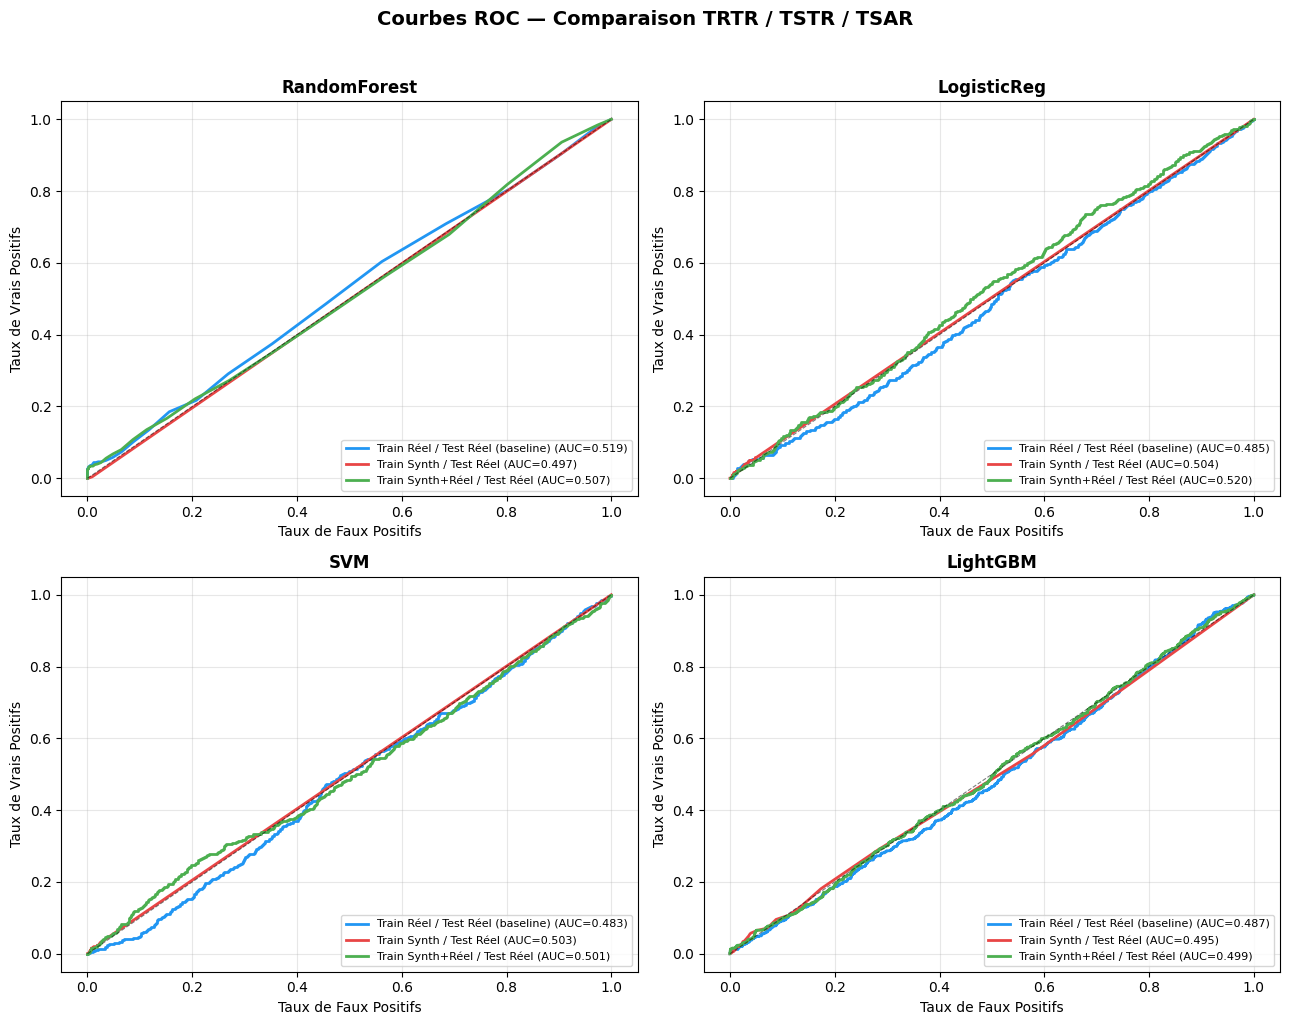

💾 Sauvegardé : roc_curves_comparison.png


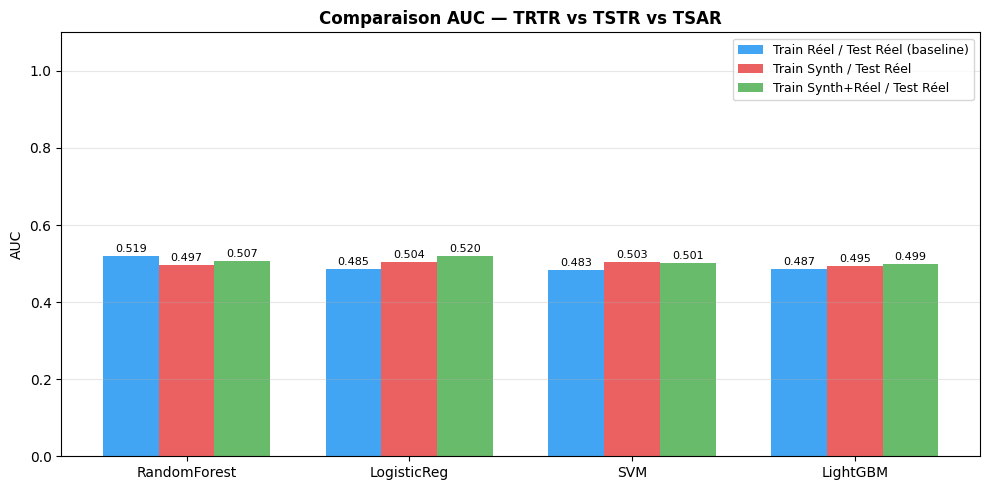

💾 Sauvegardé : comparison_auc.png


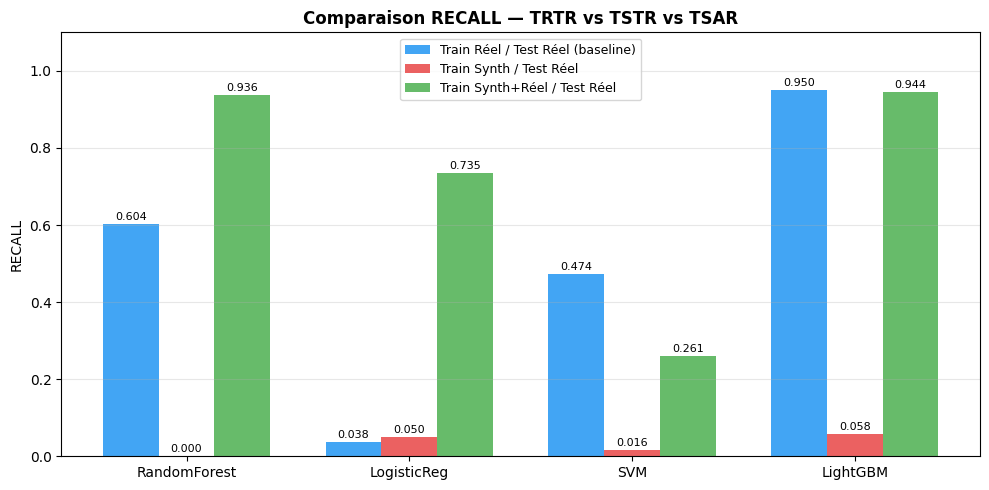

💾 Sauvegardé : comparison_recall.png

💾 Résultats sauvegardés dans resultats_tstr.json


In [11]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_curve, auc, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════
# 1. CHARGEMENT DES DONNÉES
# ═══════════════════════════════════════════════════════════

def load_real_data(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    print(f"✅ Données réelles chargées : {df.shape}")
    print(df["Fraudulent"].value_counts().to_string())
    return df


def load_synthetic_data(json_path: str) -> pd.DataFrame:
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.DataFrame(data["transactions"])
    print(f"\n✅ Données synthétiques chargées : {df.shape}")
    print(df["Fraudulent"].value_counts().to_string())
    return df


# ═══════════════════════════════════════════════════════════
# 2. PREPROCESSING (réutilise la logique du notebook)
# ═══════════════════════════════════════════════════════════

def preprocess(df: pd.DataFrame, fit_encoders: dict = None) -> tuple:
    """
    Encode les variables catégorielles et sépare X / y.
    Si fit_encoders est fourni, applique les encodeurs existants
    (cas où on encode les synth. avec les encodeurs du réel).
    Retourne (X, y, encoders).
    """
    df = df.copy()

    # Suppression des colonnes non prédictives
    drop_cols = [c for c in ["User_ID", "Transaction_ID"] if c in df.columns]
    df.drop(columns=drop_cols, inplace=True, errors="ignore")

    # Valeurs manquantes : remplacées par la moyenne / mode
    for col in df.select_dtypes(include=["float64", "int64"]).columns:
        if col != "Fraudulent":
            df[col].fillna(df[col].mean(), inplace=True)
    for col in df.select_dtypes(include=["object", "category"]).columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

    y = df["Fraudulent"].astype(int)
    X = df.drop(columns=["Fraudulent"])

    encoders = fit_encoders if fit_encoders else {}
    for col in X.select_dtypes(include=["object", "category"]).columns:
        if col in encoders:
            # Gestion des catégories inconnues dans les synth.
            le = encoders[col]
            X[col] = X[col].apply(
                lambda v: le.transform([v])[0] if v in le.classes_ else -1
            )
        else:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            encoders[col] = le

    # Alignement des colonnes (synth. peut avoir des colonnes différentes)
    return X, y, encoders


def align_columns(X_source: pd.DataFrame, X_target: pd.DataFrame) -> pd.DataFrame:
    """Aligne les colonnes de X_source sur X_target (remplissage à 0 si manquant)."""
    for col in X_target.columns:
        if col not in X_source.columns:
            X_source[col] = 0
    return X_source[X_target.columns]


# ═══════════════════════════════════════════════════════════
# 3. MODÈLES (repris du notebook)
# ═══════════════════════════════════════════════════════════

MODELS = {
    "RandomForest":   RandomForestClassifier(n_estimators=100, random_state=42),
    "LogisticReg":    LogisticRegression(max_iter=1000, random_state=42),
    "SVM":            SVC(kernel="rbf", C=5, gamma="scale",
                          probability=True, random_state=42),
    "LightGBM":       lgb.LGBMClassifier(learning_rate=0.09, max_depth=-5,
                                          random_state=42, verbose=-1),
}


def evaluate_model(model, X_train, y_train, X_test, y_test) -> dict:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba_raw = model.predict_proba(X_test)

    # ── Correction : une seule classe apprise ──────────────
    classes = list(model.classes_)
    if 1 not in classes:
        # Le modèle n'a vu que des 0 → probabilité fraude = 0 partout
        y_pred_proba = np.zeros(len(X_test))
    elif 0 not in classes:
        # Le modèle n'a vu que des 1 → probabilité fraude = 1 partout
        y_pred_proba = np.ones(len(X_test))
    else:
        y_pred_proba = y_pred_proba_raw[:, 1]
    # ────────────────────────────────────────────────────────

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    auc_score = auc(fpr, tpr)

    youden   = tpr - fpr
    best_idx = np.argmax(youden)
    best_thresh = thresholds[best_idx]
    y_pred_opt  = (y_pred_proba >= best_thresh).astype(int)

    tn = np.sum((y_pred_opt == 0) & (np.array(y_test) == 0))
    fp = np.sum((y_pred_opt == 1) & (np.array(y_test) == 0))
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        "auc":         round(auc_score, 4),
        "accuracy":    round(accuracy_score(y_test, y_pred), 4),
        "recall":      round(recall_score(y_test, y_pred_opt, zero_division=0), 4),
        "specificity": round(specificity, 4),
        "precision":   round(precision_score(y_test, y_pred_opt, zero_division=0), 4),
        "f1":          round(f1_score(y_test, y_pred_opt, zero_division=0), 4),
        "youden":      round(float(youden[best_idx]), 4),
        "threshold":   round(float(best_thresh), 4),
        "fpr": fpr, "tpr": tpr,
    }


# ═══════════════════════════════════════════════════════════
# 4. TROIS PROTOCOLES D'ENTRAÎNEMENT
# ═══════════════════════════════════════════════════════════
#
#  A) TRTR — Train Real  / Test Real  (baseline du notebook)
#  B) TSTR — Train Synth / Test Real  (qualité des synth.)
#  C) TSAR — Train Synth+Real / Test Real (apport des synth.)
#
# ═══════════════════════════════════════════════════════════

def run_experiments(df_real, df_synth, test_size=0.2):
    X_real, y_real, encoders = preprocess(df_real)
    X_synth, y_synth, _      = preprocess(df_synth, fit_encoders=encoders)
    X_synth = align_columns(X_synth, X_real)

    X_train_r, X_test, y_train_r, y_test = train_test_split(
        X_real, y_real, test_size=test_size, random_state=42, stratify=y_real
    )

    # ── Correction TSTR : enrichir le synth. avec des légitimes réelles ──
    # Sans transactions légitimes, TSTR est trivial (modèle prédit toujours 1)
    # On prend autant de légitimes réelles que de fraudes synthétiques
    real_legit = X_train_r[y_train_r == 0]
    y_real_legit = y_train_r[y_train_r == 0]
    n_legit_to_add = min(len(real_legit), len(X_synth))

    real_legit_sample   = real_legit.sample(n=n_legit_to_add, random_state=42)
    y_legit_sample      = y_real_legit.loc[real_legit_sample.index]

    X_synth_balanced = pd.concat([X_synth, real_legit_sample], ignore_index=True)
    y_synth_balanced = pd.concat(
        [y_synth.reset_index(drop=True),
         y_legit_sample.reset_index(drop=True)],
        ignore_index=True
    )
    print(f"  TSTR — train : {y_synth_balanced.value_counts().to_dict()}")
    # ─────────────────────────────────────────────────────────────────────

    # ── TSAR : données réelles + fraudes synthétiques (augmentation classe minoritaire)
    # Les synth. sont tous Fraudulent=1 → enrichit uniquement la classe fraude
    X_train_aug = pd.concat([X_train_r, X_synth], ignore_index=True)
    y_train_aug = pd.concat(
        [y_train_r.reset_index(drop=True),
         y_synth.reset_index(drop=True)],
        ignore_index=True
    )
    print(f"  TSAR — train : {y_train_aug.value_counts().to_dict()}")

    results = {}
    for model_name, model_proto in MODELS.items():
        print(f"\n  📊 {model_name}...", flush=True)
        from sklearn.base import clone
        results[model_name] = {
            "TRTR": evaluate_model(clone(model_proto), X_train_r, y_train_r, X_test, y_test),
            "TSTR": evaluate_model(clone(model_proto), X_synth_balanced, y_synth_balanced, X_test, y_test),
            "TSAR": evaluate_model(clone(model_proto), X_train_aug, y_train_aug, X_test, y_test),
        }

    return results, X_test, y_test


# ═══════════════════════════════════════════════════════════
# 5. VISUALISATION (style notebook)
# ═══════════════════════════════════════════════════════════

PROTOCOL_COLORS = {
    "TRTR": "#2196F3",   # bleu  — baseline réel
    "TSTR": "#E84545",   # rouge — synthétique pur
    "TSAR": "#4CAF50",   # vert  — augmenté
}
PROTOCOL_LABELS = {
    "TRTR": "Train Réel / Test Réel (baseline)",
    "TSTR": "Train Synth / Test Réel",
    "TSAR": "Train Synth+Réel / Test Réel",
}

def plot_roc_curves(results: dict):
    """Courbes ROC comparatives — une sous-figure par modèle."""
    n = len(results)
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    axes = axes.flatten()

    for ax, (model_name, protocols) in zip(axes, results.items()):
        for proto, metrics in protocols.items():
            ax.plot(
                metrics["fpr"], metrics["tpr"],
                color=PROTOCOL_COLORS[proto],
                label=f"{PROTOCOL_LABELS[proto]} (AUC={metrics['auc']:.3f})",
                linewidth=2
            )
        ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.5)
        ax.set_title(model_name, fontsize=12, fontweight="bold")
        ax.set_xlabel("Taux de Faux Positifs")
        ax.set_ylabel("Taux de Vrais Positifs")
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(alpha=0.3)

    plt.suptitle("Courbes ROC — Comparaison TRTR / TSTR / TSAR",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("roc_curves_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Sauvegardé : roc_curves_comparison.png")


def build_summary_table(results: dict) -> pd.DataFrame:
    """
    Tableau récapitulatif au même format multi-index que le notebook.
    """
    metrics_to_show = ["auc", "recall", "specificity", "precision", "f1", "youden"]

    index   = pd.Index(results.keys(), name="Modèle")
    columns = pd.MultiIndex.from_tuples(
        [(proto, m)
         for proto in ["TRTR", "TSTR", "TSAR"]
         for m in metrics_to_show],
        names=["Protocole", "Métrique"]
    )

    rows = []
    for model_name, protocols in results.items():
        row = []
        for proto in ["TRTR", "TSTR", "TSAR"]:
            for m in metrics_to_show:
                row.append(protocols[proto].get(m, float("nan")))
        rows.append(row)

    return pd.DataFrame(rows, index=index, columns=columns)


def plot_metric_bars(summary: pd.DataFrame, metric: str = "auc"):
    """Barres comparatives pour une métrique donnée."""
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(summary.index))
    width = 0.25

    for i, proto in enumerate(["TRTR", "TSTR", "TSAR"]):
        vals = summary[proto][metric].values
        bars = ax.bar(x + i * width, vals, width,
                      label=PROTOCOL_LABELS[proto],
                      color=PROTOCOL_COLORS[proto], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x + width)
    ax.set_xticklabels(summary.index, fontsize=10)
    ax.set_ylabel(metric.upper())
    ax.set_title(f"Comparaison {metric.upper()} — TRTR vs TSTR vs TSAR",
                 fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"comparison_{metric}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"💾 Sauvegardé : comparison_{metric}.png")


def tstr_score(results: dict) -> float:
    """
    Score de qualité des données synthétiques :
    ratio moyen AUC_TSTR / AUC_TRTR sur tous les modèles.
    Un score proche de 1.0 indique que les synth. sont aussi
    informatifs que les données réelles.
    """
    ratios = [
        v["TSTR"]["auc"] / v["TRTR"]["auc"]
        for v in results.values()
        if v["TRTR"]["auc"] > 0
    ]
    return round(np.mean(ratios), 4)


# ═══════════════════════════════════════════════════════════
# 6. MAIN
# ═══════════════════════════════════════════════════════════

if __name__ == "__main__":

    # ── Chargement ──────────────────────────────────────────
    df_real  = load_real_data("../Fraud Detection Dataset.csv")
    # Utiliser les données synthétiques bayésiennes (équilibrées)
    df_synth = load_synthetic_data("transactions_synthetiques_bayes.json")

    # ── Expériences ─────────────────────────────────────────
    print("\n🚀 Lancement des expériences (TRTR / TSTR / TSAR)...")
    results, X_test, y_test = run_experiments(df_real, df_synth)

    # ── Tableau récapitulatif ────────────────────────────────
    summary = build_summary_table(results)
    print("\n=== Tableau récapitulatif ===")
    print(summary.to_string())

    # ── Score TSTR global ────────────────────────────────────
    score = tstr_score(results)
    print(f"\n📈 Score TSTR global (AUC_TSTR / AUC_TRTR) : {score:.4f}")
    if score >= 0.90:
        print("   ✅ Excellent — les données synthétiques sont très proches du réel")
    elif score >= 0.75:
        print("   ✅ Bon — les données capturent bien la structure")
    elif score >= 0.60:
        print("   ⚠️  Acceptable — à améliorer (plus d'échantillons, meilleur prompt)")
    else:
        print("   ❌ Insuffisant — les synth. n'apportent pas d'information utile")

    # ── Visualisations ───────────────────────────────────────
    plot_roc_curves(results)
    plot_metric_bars(summary, metric="auc")
    plot_metric_bars(summary, metric="recall")

    # ── Sauvegarde JSON ──────────────────────────────────────
    exportable = {
        model: {
            proto: {k: v for k, v in m.items() if k not in ("fpr", "tpr")}
            for proto, m in protocols.items()
        }
        for model, protocols in results.items()
    }
    exportable["tstr_score"] = score
    with open("resultats_tstr.json", "w", encoding="utf-8") as f:
        json.dump(exportable, f, indent=2, ensure_ascii=False)
    print("\n💾 Résultats sauvegardés dans resultats_tstr.json")

In [12]:
!pip install imblearn


══════════════════════════════════════════════════════════════════════
  CHARGEMENT DES DONNÉES
══════════════════════════════════════════════════════════════════════
✅ Données réelles   : 51,000 lignes | Fraudes = 2510 (4.9%)
✅ Données synthétiques : 10,000 lignes | Fraudes = 10000 (100.0%)

══════════════════════════════════════════════════════════════════════
  PREPROCESSING
══════════════════════════════════════════════════════════════════════
  Colonnes réelles  : ['Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method']

  Train réel : 40,800 obs | Fraudes=2008 (4.9%)
  Test       : 10,200 obs | Fraudes=502 (4.9%)
  ⚠️  Colonnes absentes des synthétiques, remplies à 0 : {'Previous_Fraudulent_Transactions', 'Transaction_Amount'}

  Synthétiques pgmpy : 10,000 obs | Fraudes=10000 (100.0%)

  Application SMOTE (sampling_strategy=0.25)...
  Après

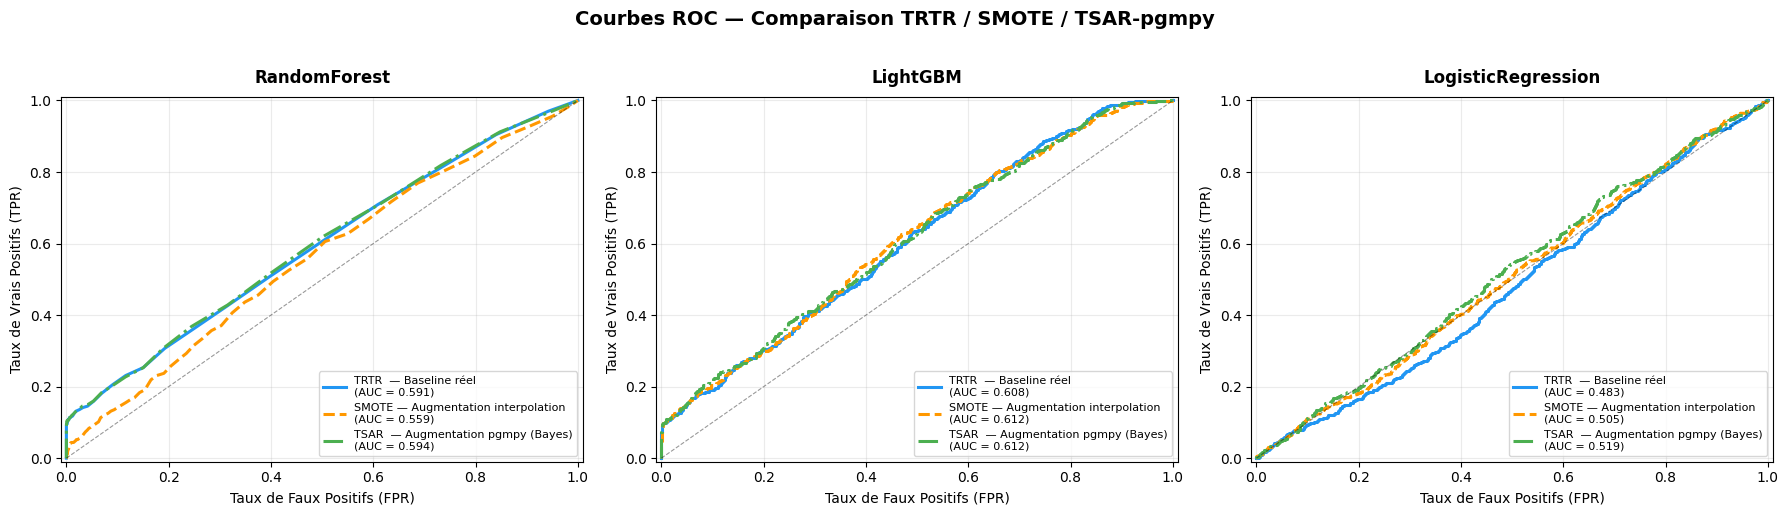

💾 Sauvegardé : roc_smote_vs_pgmpy.png


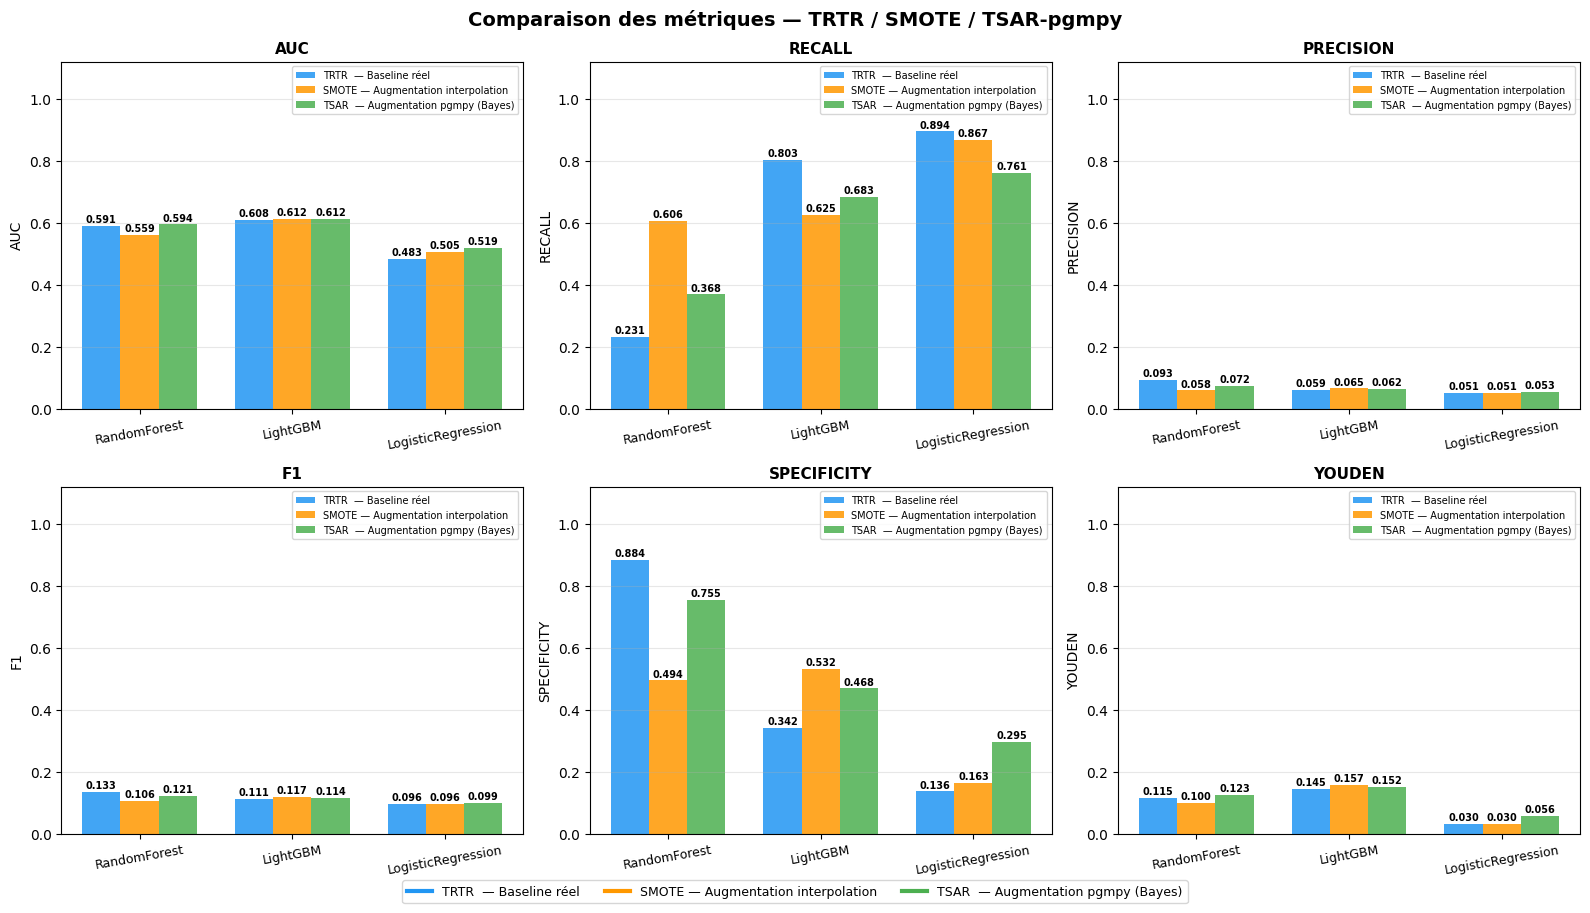

💾 Sauvegardé : metrics_smote_vs_pgmpy.png


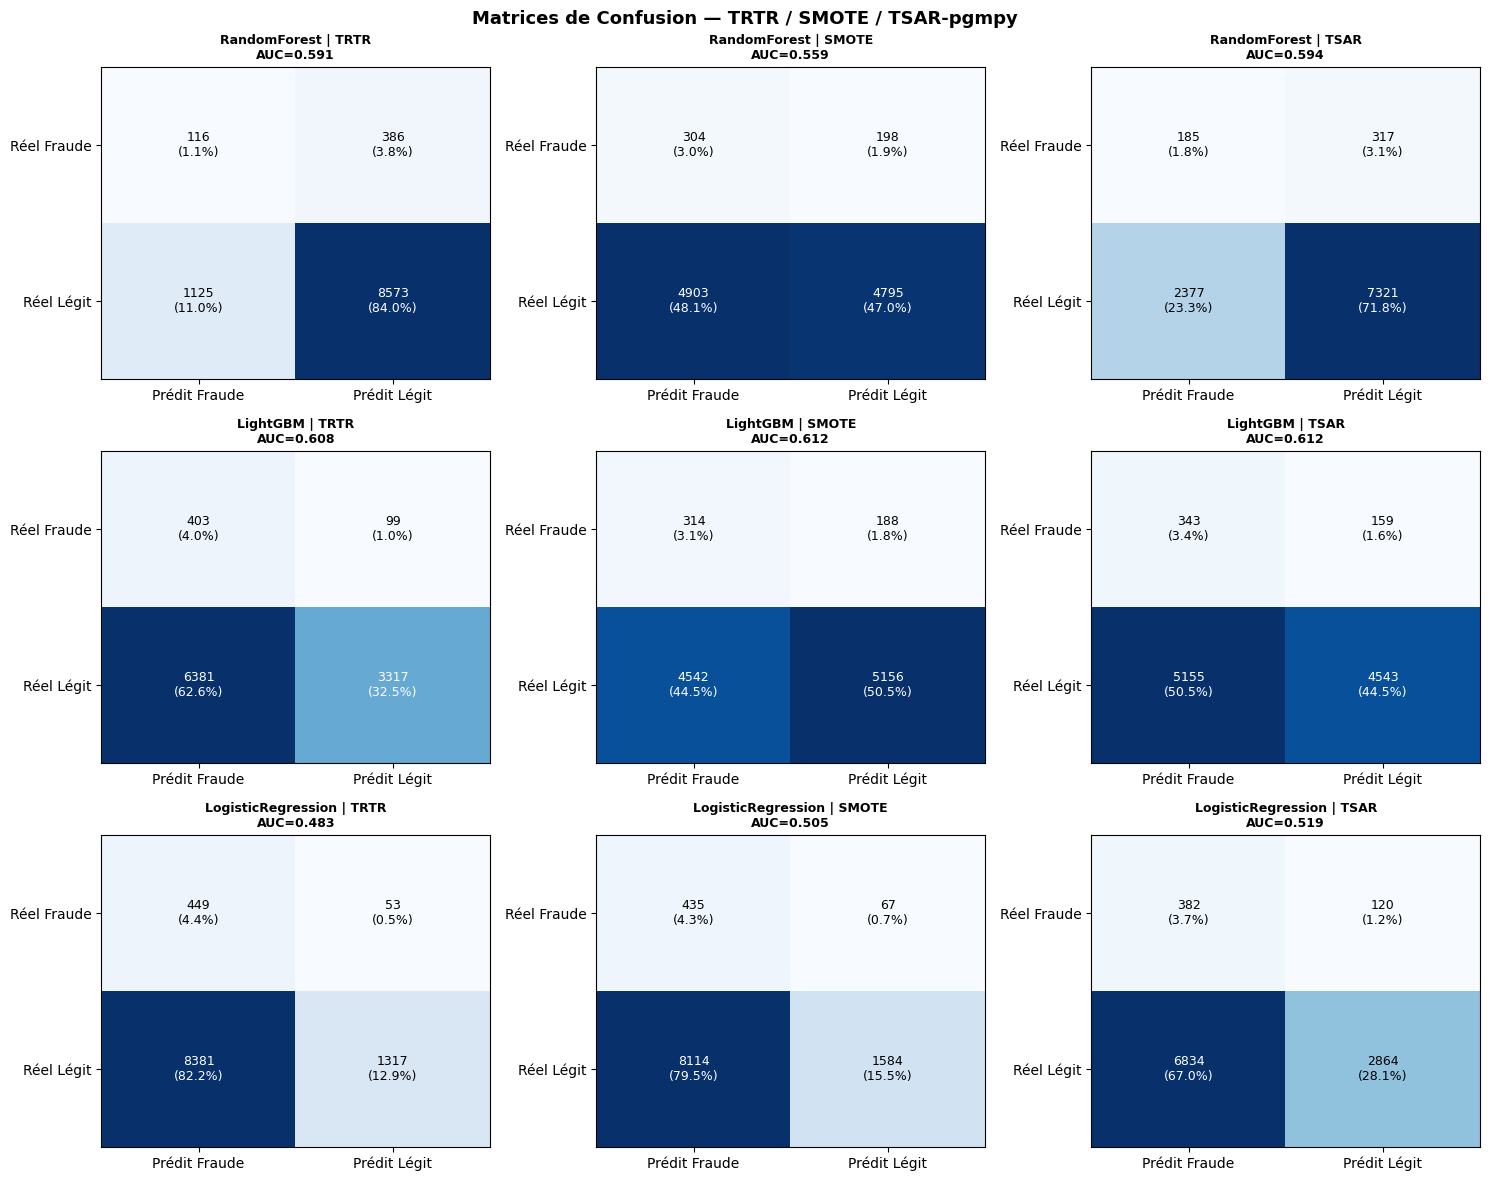

💾 Sauvegardé : confusion_smote_vs_pgmpy.png

💾 Résultats JSON sauvegardés : benchmark_results.json


In [9]:
"""
benchmark_smote_vs_pgmpy.py
═══════════════════════════════════════════════════════════════════════════════
Benchmark comparatif : SMOTE vs données synthétiques pgmpy (Réseau Bayésien)
───────────────────────────────────────────────────────────────────────────────

Reproduit EXACTEMENT la logique du notebook d'analyse descriptive :
  • Même preprocessing (imputation conditionnelle + LabelEncoder)
  • Mêmes modèles : RandomForest, LightGBM, LogisticRegression
  • Mêmes métriques : AUC, Recall, Precision, F1, Youden, Confusion matrix
  • Même split 80/20 stratifié

Protocoles comparés :
  ① TRTR  — Train Real     / Test Real  (baseline sans augmentation)
  ② SMOTE — Train Real+SMOTE / Test Real (comme le notebook)
  ③ TSAR  — Train Real+pgmpy / Test Real (notre approche bayésienne)

Usage :
    python benchmark_smote_vs_pgmpy.py \
        --csv  "Fraud Detection Dataset.csv" \
        --json "transactions_synthetiques_bayes.json"
"""

import argparse
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, auc, precision_score, recall_score,
    f1_score, accuracy_score, confusion_matrix, classification_report
)
import lightgbm as lgb
from imblearn.over_sampling import SMOTE


# ═══════════════════════════════════════════════════════════════════════════════
# 1. CHARGEMENT
# ═══════════════════════════════════════════════════════════════════════════════

def load_real(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    print(f"✅ Données réelles   : {df.shape[0]:,} lignes | "
          f"Fraudes = {df['Fraudulent'].sum()} ({df['Fraudulent'].mean():.1%})")
    return df


def load_synth(json_path: str) -> pd.DataFrame:
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.DataFrame(data["transactions"])
    n_fraud = (df["Fraudulent"].astype(int) == 1).sum()
    print(f"✅ Données synthétiques : {df.shape[0]:,} lignes | "
          f"Fraudes = {n_fraud} ({n_fraud/len(df):.1%})")
    return df


# ═══════════════════════════════════════════════════════════════════════════════
# 2. PREPROCESSING — fidèle au notebook
# ═══════════════════════════════════════════════════════════════════════════════

def preprocess_notebook_style(df: pd.DataFrame,
                               encoders: dict = None,
                               ref_columns: list = None) -> tuple:
    """
    Reproduit exactement la logique du notebook :
      1. Supprime Transaction_ID et User_ID
      2. Imputation conditionnelle sur Fraudulent (moyenne / mode par groupe)
      3. LabelEncoder sur toutes les colonnes object/category

    Si `encoders` est fourni → on applique les encodeurs existants (pour les synth.)
    Si `ref_columns` est fourni → on aligne les colonnes sur ce référentiel
    
    Retourne (X, y, encoders).
    """
    df = df.copy()

    # Suppression des identifiants
    df.drop(columns=["Transaction_ID", "User_ID"], errors="ignore", inplace=True)

    y = df["Fraudulent"].astype(int)
    X = df.drop(columns=["Fraudulent"])

    # ── Imputation conditionnelle (même logique que le notebook) ──────────────
    for col in X.columns:
        if X[col].isnull().any():
            if X[col].dtype in ["int64", "float64"]:
                X[col] = X.groupby(y)[col].transform(
                    lambda x: x.fillna(x.mean())
                )
            else:
                X[col] = X.groupby(y)[col].transform(
                    lambda x: x.fillna(x.mode()[0] if len(x.mode()) > 0 else "Unknown")
                )

    # ── Encodage catégoriel ───────────────────────────────────────────────────
    fit_encoders = encoders if encoders is not None else {}
    for col in X.select_dtypes(include=["object", "category"]).columns:
        if col in fit_encoders:
            le = fit_encoders[col]
            X[col] = X[col].astype(str).apply(
                lambda v: le.transform([v])[0] if v in le.classes_ else -1
            )
        else:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            fit_encoders[col] = le

    # ── Alignement des colonnes sur le référentiel réel ───────────────────────
    if ref_columns is not None:
        missing = set(ref_columns) - set(X.columns)
        if missing:
            print(f"  ⚠️  Colonnes absentes des synthétiques, remplies à 0 : {missing}")
        for col in ref_columns:
            if col not in X.columns:
                X[col] = 0
        X = X[ref_columns]

    return X, y, fit_encoders


# ═══════════════════════════════════════════════════════════════════════════════
# 3. ÉVALUATION D'UN MODÈLE — même métriques que le notebook
# ═══════════════════════════════════════════════════════════════════════════════

def evaluate(model, X_train, y_train, X_test, y_test,
             protocol_label: str = "") -> dict:
    """
    Entraîne le modèle et calcule :
      AUC, Recall, Precision, F1, Specificity, Youden, Accuracy
    avec seuil optimal par indice de Youden (comme la fonction logistic() du notebook).
    """
    model.fit(X_train, y_train)

    # Probabilités de la classe positive
    classes = list(model.classes_)
    proba_raw = model.predict_proba(X_test)
    if 1 not in classes:
        y_proba = np.zeros(len(X_test))
    elif 0 not in classes:
        y_proba = np.ones(len(X_test))
    else:
        y_proba = proba_raw[:, classes.index(1)]

    # Courbe ROC et AUC
    fpr, tpr, ths = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    # Seuil optimal — indice de Youden (même que le notebook)
    youden_vals = tpr - fpr
    best_idx    = int(np.argmax(youden_vals))
    threshold   = float(ths[best_idx])
    y_pred_opt  = (y_proba >= threshold).astype(int)

    # Métriques
    tn = int(np.sum((y_pred_opt == 0) & (np.array(y_test) == 0)))
    fp = int(np.sum((y_pred_opt == 1) & (np.array(y_test) == 0)))
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    cm = confusion_matrix(y_test, y_pred_opt, labels=[1, 0])

    return {
        "protocol":    protocol_label,
        "auc":         round(float(auc_score), 4),
        "recall":      round(float(recall_score(y_test, y_pred_opt, zero_division=0)), 4),
        "precision":   round(float(precision_score(y_test, y_pred_opt, zero_division=0)), 4),
        "f1":          round(float(f1_score(y_test, y_pred_opt, zero_division=0)), 4),
        "specificity": round(float(specificity), 4),
        "youden":      round(float(youden_vals[best_idx]), 4),
        "accuracy":    round(float(accuracy_score(y_test, y_pred_opt)), 4),
        "threshold":   round(threshold, 4),
        "fpr": fpr, "tpr": tpr,
        "cm":  cm,
        "report": classification_report(y_test, y_pred_opt, zero_division=0),
    }


# ═══════════════════════════════════════════════════════════════════════════════
# 4. PIPELINE PRINCIPAL
# ═══════════════════════════════════════════════════════════════════════════════

def run_benchmark(csv_path: str,
                  json_path: str,
                  smote_ratio: float = 0.25,
                  test_size:   float = 0.20,
                  random_state: int  = 42):
    """
    Exécute les 3 protocoles sur les 3 modèles et retourne un dict de résultats.
    """

    # ── Chargement ────────────────────────────────────────────────────────────
    print("\n" + "═"*70)
    print("  CHARGEMENT DES DONNÉES")
    print("═"*70)
    df_real  = load_real(csv_path)
    df_synth = load_synth(json_path)

    # ── Preprocessing des données réelles ─────────────────────────────────────
    print("\n" + "═"*70)
    print("  PREPROCESSING")
    print("═"*70)
    X_real, y_real, encoders = preprocess_notebook_style(df_real)
    ref_cols = list(X_real.columns)
    print(f"  Colonnes réelles  : {ref_cols}")

    # ── Split train / test (stratifié comme le notebook) ─────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X_real, y_real,
        test_size=test_size,
        random_state=random_state,
        stratify=y_real
    )
    print(f"\n  Train réel : {len(X_train):,} obs | "
          f"Fraudes={y_train.sum()} ({y_train.mean():.1%})")
    print(f"  Test       : {len(X_test):,} obs | "
          f"Fraudes={y_test.sum()} ({y_test.mean():.1%})")

    # ── Preprocessing des données synthétiques ────────────────────────────────
    X_synth, y_synth, _ = preprocess_notebook_style(
        df_synth, encoders=encoders, ref_columns=ref_cols
    )
    print(f"\n  Synthétiques pgmpy : {len(X_synth):,} obs | "
          f"Fraudes={y_synth.sum()} ({y_synth.mean():.1%})")

    # ── SMOTE sur le train réel (même paramétrage que le notebook) ────────────
    print(f"\n  Application SMOTE (sampling_strategy={smote_ratio:.2f})...")
    sm = SMOTE(sampling_strategy=smote_ratio / (1 - smote_ratio), random_state=random_state)
    X_smote, y_smote = sm.fit_resample(X_train, y_train)
    print(f"  Après SMOTE : {len(X_smote):,} obs | "
          f"Fraudes={y_smote.sum()} ({y_smote.mean():.1%})")

    # ── Augmentation pgmpy : train réel + synthétiques (TSAR) ────────────────
    X_tsar = pd.concat([X_train, X_synth], ignore_index=True)
    y_tsar = pd.concat(
        [y_train.reset_index(drop=True), y_synth.reset_index(drop=True)],
        ignore_index=True
    )
    print(f"  Après augmentation pgmpy : {len(X_tsar):,} obs | "
          f"Fraudes={y_tsar.sum()} ({y_tsar.mean():.1%})")
    # Comparer les distributions du train augmenté vs test
    print("Train TSAR - distribution Fraudulent :")
    print(y_tsar.value_counts(normalize=True), flush=True)

    print("\nTest - distribution Fraudulent :")
    print(y_test.value_counts(normalize=True),flush=True)
    # ── Définition des modèles ─────────────────────────────────────────────────
    from sklearn.base import clone

    MODELS = {
        "RandomForest": RandomForestClassifier(
            n_estimators=100, random_state=random_state
        ),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05,
            num_leaves=31, random_state=random_state, verbose=-1
        ),
        "LogisticRegression": LogisticRegression(
            max_iter=1000, random_state=random_state
        ),
    }

    PROTOCOLS = {
        "TRTR":  (X_train,  y_train,  "Train Réel / Test Réel (baseline)"),
        "SMOTE": (X_smote,  y_smote,  "Train Réel+SMOTE / Test Réel"),
        "TSAR":  (X_tsar,   y_tsar,   "Train Réel+pgmpy / Test Réel"),
    }

    # ── Entraînement & évaluation ──────────────────────────────────────────────
    print("\n" + "═"*70)
    print("  ENTRAÎNEMENT & ÉVALUATION")
    print("═"*70)

    results = {}
    for model_name, model_proto in MODELS.items():
        results[model_name] = {}
        for proto_key, (X_tr, y_tr, label) in PROTOCOLS.items():
            print(f"  ▸ {model_name:20s} | {proto_key} ...", end=" ", flush=True)
            m = evaluate(
                clone(model_proto), X_tr, y_tr, X_test, y_test,
                protocol_label=label
            )
            results[model_name][proto_key] = m
            print(f"AUC={m['auc']:.3f}  Recall={m['recall']:.3f}  "
                  f"Precision={m['precision']:.3f}  F1={m['f1']:.3f}")

    return results, X_test, y_test


# ═══════════════════════════════════════════════════════════════════════════════
# 5. AFFICHAGE TEXTE
# ═══════════════════════════════════════════════════════════════════════════════

def print_summary(results: dict):
    """Tableau récapitulatif multi-index (même style que le notebook)."""
    metrics = ["auc", "recall", "precision", "f1", "specificity", "youden"]
    protocols = ["TRTR", "SMOTE", "TSAR"]

    print("\n" + "═"*70)
    print("  TABLEAU RÉCAPITULATIF")
    print("═"*70)

    rows = []
    for model_name, protos in results.items():
        row = {"Modèle": model_name}
        for proto in protocols:
            for m in metrics:
                row[f"{proto}_{m}"] = protos[proto][m]
        rows.append(row)

    df_summary = pd.DataFrame(rows).set_index("Modèle")

    # Affichage par métrique
    for m in metrics:
        cols = [f"{p}_{m}" for p in protocols]
        sub  = df_summary[cols].copy()
        sub.columns = protocols
        print(f"\n  {m.upper()}")
        print(sub.to_string())

    return df_summary


def print_classification_reports(results: dict):
    """Affiche les rapports de classification pour chaque modèle/protocole."""
    print("\n" + "═"*70)
    print("  RAPPORTS DE CLASSIFICATION (seuil Youden)")
    print("═"*70)
    for model_name, protos in results.items():
        for proto, m in protos.items():
            print(f"\n  ── {model_name} | {proto} (threshold={m['threshold']}) ──")
            print(m["report"])
            cm = m["cm"]
            print(f"  Matrice de confusion [labels : 1=Fraude, 0=Légit] :")
            print(f"  TP={cm[0,0]}  FN={cm[0,1]}  FP={cm[1,0]}  TN={cm[1,1]}")


# ═══════════════════════════════════════════════════════════════════════════════
# 6. VISUALISATIONS
# ═══════════════════════════════════════════════════════════════════════════════

COLORS = {
    "TRTR":  "#2196F3",   # bleu
    "SMOTE": "#FF9800",   # orange
    "TSAR":  "#4CAF50",   # vert
}
STYLES = {
    "TRTR":  "-",
    "SMOTE": "--",
    "TSAR":  "-.",
}
LABELS = {
    "TRTR":  "TRTR  — Baseline réel",
    "SMOTE": "SMOTE — Augmentation interpolation",
    "TSAR":  "TSAR  — Augmentation pgmpy (Bayes)",
}


def plot_roc_curves(results: dict, save_path: str = "roc_smote_vs_pgmpy.png"):
    """Courbes ROC : une sous-figure par modèle, 3 courbes par figure."""
    n_models = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    for ax, (model_name, protos) in zip(axes, results.items()):
        for proto, m in protos.items():
            ax.plot(
                m["fpr"], m["tpr"],
                color=COLORS[proto],
                linestyle=STYLES[proto],
                linewidth=2.2,
                label=f"{LABELS[proto]}\n(AUC = {m['auc']:.3f})"
            )
        ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.4)
        ax.set_title(model_name, fontsize=12, fontweight="bold", pad=10)
        ax.set_xlabel("Taux de Faux Positifs (FPR)")
        ax.set_ylabel("Taux de Vrais Positifs (TPR)")
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(alpha=0.25)
        ax.set_xlim([-0.01, 1.01])
        ax.set_ylim([-0.01, 1.01])

    fig.suptitle(
        "Courbes ROC — Comparaison TRTR / SMOTE / TSAR-pgmpy",
        fontsize=14, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"💾 Sauvegardé : {save_path}")


def plot_metric_comparison(results: dict,
                            metrics: list = None,
                            save_path: str = "metrics_smote_vs_pgmpy.png"):
    """
    Grille de barres groupées : une sous-figure par métrique, une barre par protocole.
    """
    if metrics is None:
        metrics = ["auc", "recall", "precision", "f1", "specificity", "youden"]

    model_names = list(results.keys())
    n_models    = len(model_names)
    n_metrics   = len(metrics)
    protocols   = ["TRTR", "SMOTE", "TSAR"]
    x           = np.arange(n_models)
    width       = 0.25

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for ax_idx, metric in enumerate(metrics):
        ax = axes[ax_idx]
        for i, proto in enumerate(protocols):
            vals = [results[m][proto][metric] for m in model_names]
            bars = ax.bar(
                x + i * width, vals, width,
                label=LABELS[proto],
                color=COLORS[proto], alpha=0.85
            )
            for bar, v in zip(bars, vals):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom",
                    fontsize=7, fontweight="bold"
                )

        ax.set_xticks(x + width)
        ax.set_xticklabels(model_names, fontsize=9, rotation=10)
        ax.set_ylabel(metric.upper(), fontsize=10)
        ax.set_title(metric.upper(), fontsize=11, fontweight="bold")
        ax.set_ylim(0, 1.12)
        ax.grid(axis="y", alpha=0.3)
        ax.legend(fontsize=7, loc="upper right")

    # Légende globale en bas
    legend_elements = [
        Line2D([0], [0], color=COLORS[p], linewidth=3, label=LABELS[p])
        for p in protocols
    ]
    fig.legend(
        handles=legend_elements,
        loc="lower center", ncol=3,
        fontsize=9, bbox_to_anchor=(0.5, -0.02),
        frameon=True
    )

    fig.suptitle(
        "Comparaison des métriques — TRTR / SMOTE / TSAR-pgmpy",
        fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"💾 Sauvegardé : {save_path}")


def plot_confusion_matrices(results: dict,
                             save_path: str = "confusion_smote_vs_pgmpy.png"):
    """Matrices de confusion pour chaque modèle × protocole."""
    models    = list(results.keys())
    protocols = ["TRTR", "SMOTE", "TSAR"]
    n_m, n_p  = len(models), len(protocols)

    fig, axes = plt.subplots(n_m, n_p, figsize=(5 * n_p, 4 * n_m))

    for i, model_name in enumerate(models):
        for j, proto in enumerate(protocols):
            ax = axes[i][j]
            cm = results[model_name][proto]["cm"]
            # Affichage en valeur absolue + pourcentage
            total = cm.sum()
            annot = np.array(
                [[f"{cm[r,c]}\n({cm[r,c]/total*100:.1f}%)"
                  for c in range(cm.shape[1])]
                 for r in range(cm.shape[0])]
            )
            im = ax.imshow(cm, interpolation="nearest",
                           cmap=plt.cm.Blues, aspect="auto")
            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels(["Prédit Fraude", "Prédit Légit"])
            ax.set_yticklabels(["Réel Fraude", "Réel Légit"])
            for r in range(2):
                for c in range(2):
                    ax.text(c, r, annot[r, c], ha="center", va="center",
                            fontsize=9, color="white" if cm[r, c] > cm.max() / 2 else "black")
            auc_v = results[model_name][proto]["auc"]
            ax.set_title(
                f"{model_name} | {proto}\nAUC={auc_v:.3f}",
                fontsize=9, fontweight="bold"
            )

    fig.suptitle(
        "Matrices de Confusion — TRTR / SMOTE / TSAR-pgmpy",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"💾 Sauvegardé : {save_path}")


# ═══════════════════════════════════════════════════════════════════════════════
# 7. SCORE DE QUALITÉ
# ═══════════════════════════════════════════════════════════════════════════════

def print_quality_scores(results: dict):
    """
    Compare les gains apportés par SMOTE et pgmpy par rapport à TRTR.
    Un ratio proche de 1.0 indique que la méthode préserve les performances baseline.
    Un ratio > 1.0 indique un apport positif.
    """
    print("\n" + "═"*70)
    print("  SCORES DE QUALITÉ (ratio vs TRTR baseline)")
    print("═"*70)
    for metric in ["auc", "recall", "f1"]:
        print(f"\n  {metric.upper()} — ratio méthode / TRTR :")
        for model_name, protos in results.items():
            baseline = protos["TRTR"][metric]
            r_smote  = protos["SMOTE"][metric] / baseline if baseline > 0 else 0
            r_tsar   = protos["TSAR"][metric]  / baseline if baseline > 0 else 0
            smote_flag = "✅" if r_smote >= 1.0 else ("⚠️" if r_smote >= 0.9 else "❌")
            tsar_flag  = "✅" if r_tsar  >= 1.0 else ("⚠️" if r_tsar  >= 0.9 else "❌")
            print(f"    {model_name:20s} | SMOTE={r_smote:.3f} {smote_flag} | "
                  f"pgmpy={r_tsar:.3f} {tsar_flag}")

    # Score global (moyenne AUC tous modèles)
    smote_global = np.mean([
        v["SMOTE"]["auc"] / v["TRTR"]["auc"]
        for v in results.values() if v["TRTR"]["auc"] > 0
    ])
    tsar_global = np.mean([
        v["TSAR"]["auc"] / v["TRTR"]["auc"]
        for v in results.values() if v["TRTR"]["auc"] > 0
    ])
    print(f"\n  Score global AUC moyen :")
    print(f"    SMOTE / TRTR = {smote_global:.4f}")
    print(f"    pgmpy / TRTR = {tsar_global:.4f}")

    winner = "SMOTE" if smote_global > tsar_global else "pgmpy (Réseau Bayésien)"
    print(f"\n  🏆 Meilleure méthode d'augmentation : {winner}")


# ═══════════════════════════════════════════════════════════════════════════════
# 8. SAUVEGARDE JSON
# ═══════════════════════════════════════════════════════════════════════════════

def save_results(results: dict, path: str = "benchmark_results.json"):
    exportable = {
        model: {
            proto: {k: v for k, v in m.items()
                    if k not in ("fpr", "tpr", "cm", "report")}
            for proto, m in protos.items()
        }
        for model, protos in results.items()
    }
    with open(path, "w", encoding="utf-8") as f:
        json.dump(exportable, f, indent=2, ensure_ascii=False)
    print(f"\n💾 Résultats JSON sauvegardés : {path}")


# ═══════════════════════════════════════════════════════════════════════════════
# 9. POINT D'ENTRÉE
# ═══════════════════════════════════════════════════════════════════════════════

# ── Paramètres à adapter ──────────────────────────────────────
CSV_PATH    = "../Fraud Detection Dataset.csv"
JSON_PATH   = "transactions_synthetiques_bayes.json"
SMOTE_RATIO = 0.25
# ─────────────────────────────────────────────────────────────

results, X_test, y_test = run_benchmark(
    csv_path=CSV_PATH,
    json_path=JSON_PATH,
    smote_ratio=SMOTE_RATIO,
)

print_summary(results)
print_classification_reports(results)
print_quality_scores(results)

plot_roc_curves(results,         save_path="roc_smote_vs_pgmpy.png")
plot_metric_comparison(results,  save_path="metrics_smote_vs_pgmpy.png")
plot_confusion_matrices(results, save_path="confusion_smote_vs_pgmpy.png")

save_results(results, path="benchmark_results.json")


In [ ]:
import numpy as np
# ─────────────────────────────────────────────────────────────────────────────
# 13. TABLES DE PROBABILITES CONDITIONNELLES (CPT) — MAXIMUM DE VRAISEMBLANCE
# ─────────────────────────────────────────────────────────────────────────────
# Dépendances : pip install pgmpy

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.factors.discrete import TabularCPD
import warnings
warnings.filterwarnings("ignore")


# ─── 13.1  DISCRETISATION DES VARIABLES ─────────────────────────────────────

# Intervalles et labels pour la discrétisation de Time_of_Transaction
BINS_HEURE  = [-0.1, 5.9, 11.9, 17.9, 23.1]
LABELS_HEURE = ["nuit(0-5)", "matin(6-11)", "apres-midi(12-17)", "soir(18-23)"]

# Intervalles et labels pour Account_Age (quartiles)
LABELS_AGE = ["very_new", "new", "established", "old"]

# Labels pour Number_of_Transactions_Last_24H (tertiles)
LABELS_TX24 = ["faible", "moyen", "eleve"]

# Labels Transaction_Amount (quintiles) — imposés par l'utilisateur
LABELS_MONTANT = ["very_low", "low", "average", "high", "very_high"]


def discretiser_donnees(data: pd.DataFrame,
                         colonnes_exclues: list = None) -> pd.DataFrame:
    """
    Prépare le dataset pour pgmpy en discrétisant les variables continues.

    Règles de discrétisation :
      Transaction_Amount            → quintiles → very_low / low / average / high / very_high
      Time_of_Transaction           → tranches horaires → nuit / matin / apres-midi / soir
      Account_Age                   → quartiles → very_new / new / established / old
      Number_of_Transactions_Last_24H → tertiles → faible / moyen / eleve
      Previous_Fraudulent_Transactions → déjà discret (0-4), conservé tel quel
      Fraudulent                    → binaire 0/1, conservé tel quel
      Variables catégorielles       → converties en str

    Retourne un DataFrame entièrement discret (toutes colonnes en str).
    """
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    df = data.drop(columns=colonnes_exclues, errors="ignore").copy()
    
    # ── NOUVEAU : supprimer les valeurs parasites AVANT dropna ──────────────
    VALEURS_PARASITES = {
        "Payment_Method": ["Invalid Method"],
        "Device_Used":    ["Unknown Device"],
    }
    for col, vals in VALEURS_PARASITES.items():
        if col in df.columns:
            avant = len(df)
            df = df[~df[col].isin(vals)]
            print(f"  [{col}] Suppression de {avant - len(df)} lignes parasites ({vals})")
    
    df = df.dropna().reset_index(drop=True)

    # ── Transaction_Amount (5 bins) ──────────────────────────────────────────
    # Remplacer le qcut uniforme par des bins orientés fraude
    fraudes = df[df["Fraudulent"].astype(str) == "1"]["Transaction_Amount"]

    # Bins définis sur la distribution des fraudes
    _, bins_fraud = pd.qcut(fraudes, q=5, retbins=True, duplicates="drop")

    df["Transaction_Amount"] = pd.cut(
        df["Transaction_Amount"],
        bins=bins_fraud,
        labels=LABELS_MONTANT,
        include_lowest=True
    ).astype(str)

    # ── Time_of_Transaction (4 tranches horaires) ────────────────────────────
    if "Time_of_Transaction" in df.columns:
        try:
            df["Time_of_Transaction"] = pd.cut(
                df["Time_of_Transaction"],
                bins=BINS_HEURE, labels=LABELS_HEURE
            ).astype(str)
        except Exception as e:
            print(f"  [!] Discretisation Time_of_Transaction : {e}")

    # ── Account_Age (quartiles) ──────────────────────────────────────────────
    if "Account_Age" in df.columns:
        try:
            df["Account_Age"] = pd.qcut(
                df["Account_Age"], q=4,
                labels=LABELS_AGE, duplicates="drop"
            ).astype(str)
        except Exception as e:
            print(f"  [!] Discretisation Account_Age : {e}")

    # ── Number_of_Transactions_Last_24H (tertiles) ───────────────────────────
    if "Number_of_Transactions_Last_24H" in df.columns:
        try:
            df["Number_of_Transactions_Last_24H"] = pd.qcut(
                df["Number_of_Transactions_Last_24H"], q=3,
                labels=LABELS_TX24, duplicates="drop"
            ).astype(str)
        except Exception as e:
            print(f"  [!] Discretisation Number_of_Transactions_Last_24H : {e}")

    # ── Variables déjà discrètes ─────────────────────────────────────────────
    if "Previous_Fraudulent_Transactions" in df.columns:
        df["Previous_Fraudulent_Transactions"] = (
            df["Previous_Fraudulent_Transactions"].astype(int).astype(str)
        )

    if "Fraudulent" in df.columns:
        df["Fraudulent"] = df["Fraudulent"].astype(int).astype(str)

    # ── Toutes les autres colonnes object → str ──────────────────────────────
    for col in df.columns:
        if df[col].dtype == object or str(df[col].dtype) == "category":
            df[col] = df[col].astype(str)

    # Remplacer les éventuels "nan" résiduels
    df = df.replace("nan", np.nan).dropna().reset_index(drop=True)

    return df


def afficher_resume_discretisation(df_disc: pd.DataFrame):
    """Affiche un résumé des modalités obtenues après discrétisation."""
    print("\n" + "="*70)
    print(" RESUME DE LA DISCRETISATION")
    print("="*70)
    for col in df_disc.columns:
        modalites = sorted(df_disc[col].unique().tolist())
        n_mod = len(modalites)
        print(f"  {col:40s} → {n_mod} modalites : {modalites}")
    print("="*70 + "\n")


# ─── 13.2  CONSTRUCTION DU RESEAU BAYESIEN ───────────────────────────────────

def construire_reseau_bayesien(dag_data: dict,
                                df_disc: pd.DataFrame) -> DiscreteBayesianNetwork:
    """
    Construit un DiscreteBayesianNetwork pgmpy à partir du DAG validé.
    Vérifie que tous les nœuds et arêtes sont compatibles avec df_disc.
    """
    colonnes_dispo = set(df_disc.columns)

    # Garder seulement les arêtes dont les deux extrémités sont dans df_disc
    aretes = [
        (lien["de"], lien["vers"])
        for lien in dag_data.get("liens", [])
        if lien["de"] in colonnes_dispo and lien["vers"] in colonnes_dispo
    ]

    if not aretes:
        raise ValueError("Aucune arête valide trouvée entre les colonnes disponibles.")

    modele = DiscreteBayesianNetwork(aretes)

    # Ajouter les nœuds isolés (présents dans le DAG mais sans arête dans df_disc)
    noeuds_dag = [n for n in dag_data.get("noeuds", []) if n in colonnes_dispo]
    for noeud in noeuds_dag:
        if noeud not in modele.nodes():
            modele.add_node(noeud)

    print(f"  Reseau bayesien : {len(modele.nodes())} noeuds, "
          f"{len(modele.edges())} aretes")
    print(f"  Aretes : {list(modele.edges())}\n")

    return modele


# ─── 13.3  ESTIMATION DES CPT PAR MAXIMUM DE VRAISEMBLANCE ──────────────────

def estimer_cpt_mle(modele: DiscreteBayesianNetwork,
                     df_disc: pd.DataFrame,
                     pseudo_count: float = 0.5) -> DiscreteBayesianNetwork:
    """
    Estime les CPT par Maximum de Vraisemblance (MLE pur).

    Paramètres
    ----------
    pseudo_count : pseudo-compte ajouté à chaque cellule après le fit MLE
                   pour éviter les probabilités nulles (lissage de Jeffreys).
                   0.5 par défaut. Mettre 0.0 pour un MLE strict.
    """
    print(" Estimation des CPT par Maximum de Vraisemblance (pgmpy)...")

    colonnes_modele = list(modele.nodes())
    df_fit = df_disc[colonnes_modele].copy()

    # MLE pur : pgmpy calcule P(X | parents) = count(X, parents) / count(parents)
    modele.fit(df_fit, estimator=MaximumLikelihoodEstimator)

    # Lissage post-hoc : ajouter pseudo_count sur les valeurs numpy en place
    # et re-normaliser colonne par colonne (axe 0 = états du nœud).
    # Cela est numériquement équivalent au lissage de Laplace/Jeffreys.
    if pseudo_count > 0.0:
        for cpd in modele.cpds:
            v = cpd.values.astype(float) + pseudo_count
            # cpd.values a la forme (card_noeud, prod_cards_parents)
            # On normalise sur l'axe 0 (somme sur les états du nœud = 1)
            v_2d = v.reshape(cpd.variable_card, -1)
            v_2d = v_2d / v_2d.sum(axis=0, keepdims=True)
            cpd.values = v_2d.reshape(cpd.values.shape)

    print(f"  CPT estimees pour {len(colonnes_modele)} variables.\n")
    return modele


# ─── 13.4  AFFICHAGE DES CPT ─────────────────────────────────────────────────

def afficher_cpt(modele: DiscreteBayesianNetwork, dag_data: dict = None):
    """
    Affiche toutes les CPT sous forme de DataFrames pivotés (ordre topologique).
    Lit directement cpd.values — compatible pgmpy >= 1.0.0.
    """
    from itertools import product as iproduct

    print("\n" + "="*70)
    print(" TABLES DE PROBABILITES CONDITIONNELLES (CPT)")
    print(" Methode : Maximum de Vraisemblance (lissage de Laplace)")
    print("="*70)

    G_nx = nx.DiGraph()
    G_nx.add_edges_from(modele.edges())
    try:
        ordre = list(nx.topological_sort(G_nx))
        for n in modele.nodes():
            if n not in ordre:
                ordre.append(n)
    except Exception:
        ordre = list(modele.nodes())

    for noeud in ordre:
        if noeud not in modele.nodes():
            continue
        try:
            cpd = modele.get_cpds(noeud)
        except Exception:
            continue

        parents = cpd.variables[1:]
        etats   = cpd.state_names[noeud]
        values_2d = cpd.values.reshape(len(etats), -1)

        print(f"\n{'─'*70}")
        if parents:
            print(f"  P( {noeud} | {', '.join(parents)} )")
        else:
            print(f"  P( {noeud} )  [variable racine]")
        print(f"  Modalites : {etats}")
        print(f"{'─'*70}")

        if not parents:
            # Nœud racine : Series simple
            serie = pd.Series(
                {e: round(float(values_2d[i, 0]), 4) for i, e in enumerate(etats)},
                name="probabilite"
            )
            serie["[TOTAL]"] = round(serie.sum(), 4)
            print(serie.to_string())
        else:
            # Construire un DataFrame (configs parents en lignes, états en colonnes)
            parent_states = [cpd.state_names[p] for p in parents]
            configs = list(iproduct(*parent_states))

            rows = {}
            for j, cfg in enumerate(configs):
                cle = tuple(cfg) if len(cfg) > 1 else cfg[0]
                rows[cle] = {e: round(float(values_2d[i, j]), 4) for i, e in enumerate(etats)}

            if len(parents) == 1:
                idx = pd.Index([c for c in rows], name=parents[0])
            else:
                idx = pd.MultiIndex.from_tuples(list(rows.keys()), names=parents)

            df_cpt = pd.DataFrame(list(rows.values()), index=idx, columns=etats)
            df_cpt["[TOTAL]"] = df_cpt.sum(axis=1).round(4)
            print(df_cpt.to_string())

    print("\n" + "="*70 + "\n")
def sauvegarder_cpt(modele: DiscreteBayesianNetwork,
                     chemin: str = "cpt_dag_valide.json") -> dict:
    """
    Sérialise toutes les CPT en JSON en lisant directement cpd.values (numpy).
    Compatible pgmpy >= 1.0.0 (to_factor().to_df() ne retourne plus 'value').

    Structure :
      noeuds racines  → { "etat": proba }
      noeuds fils     → { "parent1=v1|parent2=v2": { "etat": proba } }
    """
    from itertools import product as iproduct

    cpts_dict = {}

    G_nx = nx.DiGraph()
    G_nx.add_edges_from(modele.edges())
    try:
        ordre = list(nx.topological_sort(G_nx))
        for n in modele.nodes():
            if n not in ordre:
                ordre.append(n)
    except Exception:
        ordre = list(modele.nodes())

    for noeud in ordre:
        if noeud not in modele.nodes():
            continue
        try:
            cpd = modele.get_cpds(noeud)
        except Exception:
            continue

        parents = cpd.variables[1:]
        etats   = cpd.state_names[noeud]

        # cpd.values shape : (card_noeud, card_parent1, card_parent2, ...)
        # ou (card_noeud,) si noeud racine.
        # On remet en 2D : (card_noeud, prod_cards_parents)
        values_2d = cpd.values.reshape(len(etats), -1)

        table_json = {}

        if not parents:
            # Nœud racine : { etat: proba }
            for i, etat in enumerate(etats):
                table_json[etat] = round(float(values_2d[i, 0]), 6)
        else:
            # Nœud conditionnel
            # Colonnes de values_2d = configs parents dans l'ordre du produit cartésien
            parent_states = [cpd.state_names[p] for p in parents]
            configs = list(iproduct(*parent_states))  # même ordre que pgmpy

            for j, cfg in enumerate(configs):
                cle = "|".join(f"{p}={v}" for p, v in zip(parents, cfg))
                table_json[cle] = {
                    etat: round(float(values_2d[i, j]), 6)
                    for i, etat in enumerate(etats)
                }

        cpts_dict[noeud] = {
            "parents": parents,
            "etats":   etats,
            "table":   table_json,
        }

    with open(chemin, "w", encoding="utf-8") as f:
        json.dump(cpts_dict, f, indent=2, ensure_ascii=False)

    print(f"  CPT sauvegardees : {chemin}")
    _afficher_apercu_cpt(cpts_dict)
    return cpts_dict


def _afficher_apercu_cpt(cpts_dict: dict):
    """Affiche un aperçu compact des CPT pour vérification rapide."""
    print("\n" + "="*70)
    print(" APERÇU DES CPT SAUVEGARDÉES")
    print("="*70)
    for noeud, info in cpts_dict.items():
        parents = info["parents"]
        etats   = info["etats"]
        table   = info["table"]
        n_configs = len(table) if parents else 1
        if parents:
            exemple_cle = next(iter(table))
            exemple_vals = table[exemple_cle]
            apercu = f"ex: P({noeud}|{exemple_cle}) = {exemple_vals}"
        else:
            apercu = f"P({noeud}) = {table}"
        print(f"  {noeud:40s} | parents={parents} | {len(etats)} états | {n_configs} configs")
        print(f"    {apercu[:90]}")
    print("="*70 + "\n")
def visualiser_cpt_noeud(modele: DiscreteBayesianNetwork,
                          noeud: str,
                          max_configs: int = 12):
    """
    Affiche un graphique à barres groupées pour la CPT d'un noeud donné.
    Utile pour les variables avec peu de parents.
    """
    try:
        cpd = modele.get_cpds(noeud)
    except Exception:
        print(f"  CPD introuvable pour {noeud}")
        return

    parents = cpd.variables[1:]
    etats   = cpd.state_names[noeud]
    n_etats = len(etats)

    try:
        df_cpd = cpd.to_factor().to_df()
    except Exception:
        print("  Impossible de convertir le CPD en DataFrame.")
        return

    if parents:
        # Grouper par configuration de parents
        groupes = df_cpd.groupby(parents)
        configs = list(groupes.groups.keys())
        if len(configs) > max_configs:
            configs = configs[:max_configs]
            print(f"  (Affichage limité aux {max_configs} premières configurations)")

        n_configs = len(configs)
        x = np.arange(n_configs)
        largeur = 0.8 / n_etats
        couleurs = plt.cm.Set2(np.linspace(0, 1, n_etats))

        fig, ax = plt.subplots(figsize=(max(10, n_configs * 1.5), 6),
                               facecolor="white")
        ax.set_facecolor("#f8f9fa")

        for i, etat in enumerate(etats):
            valeurs = []
            for cfg in configs:
                if isinstance(cfg, str):
                    masque = (df_cpd[parents[0]] == cfg)
                else:
                    masque = pd.Series([True] * len(df_cpd))
                    for j, p in enumerate(parents):
                        masque &= (df_cpd[p] == cfg[j])
                subset = df_cpd[masque & (df_cpd[noeud] == etat)]
                v = float(subset["value"].values[0]) if len(subset) > 0 else 0.0
                valeurs.append(v)
            ax.bar(x + i * largeur, valeurs, largeur,
                   label=etat, color=couleurs[i], alpha=0.85,
                   edgecolor="white", linewidth=0.8)

        labels_x = []
        for cfg in configs:
            if isinstance(cfg, (list, tuple)):
                labels_x.append("\n".join(f"{p}={v}" for p, v in zip(parents, cfg)))
            else:
                labels_x.append(f"{parents[0]}={cfg}")

        ax.set_xticks(x + largeur * (n_etats - 1) / 2)
        ax.set_xticklabels(labels_x, fontsize=8, rotation=30, ha="right")
        ax.set_ylabel("Probabilité", fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"P( {noeud} | {', '.join(parents)} )",
                     fontsize=14, fontweight="bold", color="#2c3e50")
        ax.legend(title=noeud, bbox_to_anchor=(1.01, 1),
                  loc="upper left", fontsize=9)
        ax.grid(axis="y", alpha=0.4, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

    else:
        # Nœud racine : graphique simple
        valeurs = [float(df_cpd[df_cpd[noeud] == e]["value"].values[0])
                   for e in etats]
        couleurs = plt.cm.Set2(np.linspace(0, 1, len(etats)))

        fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
        ax.set_facecolor("#f8f9fa")
        bars = ax.bar(etats, valeurs, color=couleurs, alpha=0.85,
                      edgecolor="white", linewidth=1.2)
        ax.set_ylabel("Probabilité", fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"P( {noeud} )  [variable racine]",
                     fontsize=14, fontweight="bold", color="#2c3e50")
        for bar, val in zip(bars, valeurs):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
        ax.grid(axis="y", alpha=0.4, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    chemin_png = f"cpt_{noeud.lower().replace(' ', '_')}.png"
    plt.savefig(chemin_png, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"  Graphique sauvegardé : {chemin_png}")


# ─── 13.7  PIPELINE CPT COMPLET ──────────────────────────────────────────────

def pipeline_cpt(dag_data: dict,
                 data: pd.DataFrame,
                 colonnes_exclues: list = None,
                 visualiser_noeuds: list = None) -> tuple:
    """
    Pipeline complet de calcul des CPT :
      1. Discrétisation des données
      2. Construction du réseau bayésien
      3. Estimation des CPT par MLE
      4. Affichage + sauvegarde
      5. Visualisation (optionnelle) de certains nœuds

    Paramètres
    ----------
    dag_data          : DAG validé (dict)
    data              : DataFrame original (non discrétisé)
    colonnes_exclues  : colonnes à ignorer
    visualiser_noeuds : liste de nœuds à visualiser (None = auto-sélection)

    Retourne (modele_bayesien, df_disc, cpts_dict).
    """
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    print("\n" + "="*70)
    print("  CALCUL DES TABLES DE PROBABILITES CONDITIONNELLES (CPT)")
    print("  Méthode : Maximum de Vraisemblance + lissage de Laplace")
    print("="*70 + "\n")

    # ── Etape 1 : Discrétisation ─────────────────────────────────────────────
    print("[Etape 1/4]  Discretisation des variables...")
    df_disc = discretiser_donnees(data, colonnes_exclues)
    afficher_resume_discretisation(df_disc)

    # ── Etape 2 : Construction du réseau ─────────────────────────────────────
    print("[Etape 2/4]  Construction du reseau bayesien...")
    try:
        modele = construire_reseau_bayesien(dag_data, df_disc)
    except ValueError as e:
        print(f"  Erreur : {e}")
        return None, df_disc, {}

    # ── Etape 3 : Estimation MLE ──────────────────────────────────────────────
    print("[Etape 3/4]  Estimation des CPT par MLE...")
    modele = estimer_cpt_mle(modele, df_disc)

    # ── Etape 4 : Affichage et sauvegarde ────────────────────────────────────
    print("[Etape 4/4]  Affichage et sauvegarde...")
    afficher_cpt(modele, dag_data)
    cpts_dict = sauvegarder_cpt(modele, "cpt_dag_valide.json")

    # ── Etape 5 : Visualisations ─────────────────────────────────────────────
    if visualiser_noeuds is None:
        # Auto : visualiser tous les nœuds avec ≤ 1 parent (CPT lisibles)
        G_nx = nx.DiGraph()
        G_nx.add_edges_from(modele.edges())
        visualiser_noeuds = [
            n for n in modele.nodes()
            if len(list(G_nx.predecessors(n))) <= 1
        ]
        print(f"\n  Noeuds visualises (<=1 parent) : {visualiser_noeuds}")

    print("\n  Génération des graphiques CPT...")
    for noeud in visualiser_noeuds:
        if noeud in modele.nodes():
            visualiser_cpt_noeud(modele, noeud)

    print("\n[OK] Pipeline CPT termine !")
    print(f"  Fichiers generes : cpt_dag_valide.json + graphiques PNG")

    return modele, df_disc, cpts_dict


# ─────────────────────────────────────────────────────────────────────────────
# POINT D'ENTREE CPT
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # ── Option A : charger le DAG validé depuis le fichier JSON ──────────────
    try:
        with open("dag_final_valide.json", "r", encoding="utf-8") as f:
            dag_valide = json.load(f)
        print("  DAG charge depuis dag_final_valide.json")
    except FileNotFoundError:
        # ── Option B : lancer la boucle de génération/validation d'abord ─────
        print("dag_final_valide.json introuvable.")
        print("  Lancement de la boucle de generation/validation...\n")
        COLONNES_EXCLUES = ["Transaction_ID", "User_ID"]
        dag_valide, _ = boucle_generation_validation(
            data=data,
            colonnes_exclues=COLONNES_EXCLUES,
            model_name=MODEL_NAME,
            max_iterations=10,
            alpha=0.05,
        )

    # ── Calcul des CPT ────────────────────────────────────────────────────────
    modele_bn, df_discretise, cpts = pipeline_cpt(
        dag_data=dag_valide,
        data=data,
        colonnes_exclues=["Transaction_ID", "User_ID"],
    )


/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Location': 'C', 'Fraudulent': 'C', 'Transaction_Type': 'C', 'Device_Used': 'C', 'Payment_Method': 'C', 'Time_of_Transaction': 'C', 'Number_of_Transactions_Last_24H': 'C', 'Account_Age': 'C'}


  DAG charge depuis dag_final_valide.json

  CALCUL DES TABLES DE PROBABILITES CONDITIONNELLES (CPT)
  Méthode : Maximum de Vraisemblance + lissage de Laplace

[Etape 1/4]  Discretisation des variables...
  [Payment_Method] Suppression de 1530 lignes parasites (['Invalid Method'])
  [Device_Used] Suppression de 1472 lignes parasites (['Unknown Device'])

 RESUME DE LA DISCRETISATION
  Transaction_Amount                       → 5 modalites : ['average', 'high', 'low', 'very_high', 'very_low']
  Transaction_Type                         → 5 modalites : ['ATM Withdrawal', 'Bank Transfer', 'Bill Payment', 'Online Purchase', 'POS Payment']
  Time_of_Transaction                      → 4 modalites : ['apres-midi(12-17)', 'matin(6-11)', 'nuit(0-5)', 'soir(18-23)']
  Device_Used                              → 3 modalites : ['Desktop', 'Mobile', 'Tablet']
  Location                                 → 8 modalites : ['Boston', 'Chicago', 'Houston', 'Los Angeles', 'Miami', 'New York', 'San Francisco'

In [ ]:
import numpy as np
# ─────────────────────────────────────────────────────────────────────────────
# 13. TABLES DE PROBABILITES CONDITIONNELLES (CPT) — MAXIMUM DE VRAISEMBLANCE
# ─────────────────────────────────────────────────────────────────────────────
# Dépendances : pip install pgmpy

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.factors.discrete import TabularCPD
import warnings
warnings.filterwarnings("ignore")


# ─── 13.1  DISCRETISATION DES VARIABLES ─────────────────────────────────────

# Intervalles et labels pour la discrétisation de Time_of_Transaction
BINS_HEURE  = [-0.1, 5.9, 11.9, 17.9, 23.1]
LABELS_HEURE = ["nuit(0-5)", "matin(6-11)", "apres-midi(12-17)", "soir(18-23)"]

# Intervalles et labels pour Account_Age (quartiles)
LABELS_AGE = ["very_new", "new", "established", "old"]

# Labels pour Number_of_Transactions_Last_24H (tertiles)
LABELS_TX24 = ["faible", "moyen", "eleve"]

# Labels Transaction_Amount (quintiles) — imposés par l'utilisateur
LABELS_MONTANT = ["very_low", "low", "average", "high", "very_high"]


def discretiser_donnees(data: pd.DataFrame,
                         colonnes_exclues: list = None) -> pd.DataFrame:
    """
    Prépare le dataset pour pgmpy en discrétisant les variables continues.

    Règles de discrétisation :
      Transaction_Amount            → quintiles → very_low / low / average / high / very_high
      Time_of_Transaction           → tranches horaires → nuit / matin / apres-midi / soir
      Account_Age                   → quartiles → very_new / new / established / old
      Number_of_Transactions_Last_24H → tertiles → faible / moyen / eleve
      Previous_Fraudulent_Transactions → déjà discret (0-4), conservé tel quel
      Fraudulent                    → binaire 0/1, conservé tel quel
      Variables catégorielles       → converties en str

    Retourne un DataFrame entièrement discret (toutes colonnes en str).
    """
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    df = data.drop(columns=colonnes_exclues, errors="ignore").copy()
    
    # ── NOUVEAU : supprimer les valeurs parasites AVANT dropna ──────────────
    VALEURS_PARASITES = {
        "Payment_Method": ["Invalid Method"],
        "Device_Used":    ["Unknown Device"],
    }
    for col, vals in VALEURS_PARASITES.items():
        if col in df.columns:
            avant = len(df)
            df = df[~df[col].isin(vals)]
            print(f"  [{col}] Suppression de {avant - len(df)} lignes parasites ({vals})")
    
    df = df.dropna().reset_index(drop=True)

    # ── Transaction_Amount (5 bins) ──────────────────────────────────────────
    # Remplacer le qcut uniforme par des bins orientés fraude
    fraudes = df[df["Fraudulent"].astype(str) == "1"]["Transaction_Amount"]

    # Bins définis sur la distribution des fraudes
    _, bins_fraud = pd.qcut(fraudes, q=5, retbins=True, duplicates="drop")

    df["Transaction_Amount"] = pd.cut(
        df["Transaction_Amount"],
        bins=bins_fraud,
        labels=LABELS_MONTANT,
        include_lowest=True
    ).astype(str)

    # ── Time_of_Transaction (4 tranches horaires) ────────────────────────────
    if "Time_of_Transaction" in df.columns:
        try:
            df["Time_of_Transaction"] = pd.cut(
                df["Time_of_Transaction"],
                bins=BINS_HEURE, labels=LABELS_HEURE
            ).astype(str)
        except Exception as e:
            print(f"  [!] Discretisation Time_of_Transaction : {e}")

    # ── Account_Age (quartiles) ──────────────────────────────────────────────
    if "Account_Age" in df.columns:
        try:
            df["Account_Age"] = pd.qcut(
                df["Account_Age"], q=4,
                labels=LABELS_AGE, duplicates="drop"
            ).astype(str)
        except Exception as e:
            print(f"  [!] Discretisation Account_Age : {e}")

    # ── Number_of_Transactions_Last_24H (tertiles) ───────────────────────────
    if "Number_of_Transactions_Last_24H" in df.columns:
        try:
            df["Number_of_Transactions_Last_24H"] = pd.qcut(
                df["Number_of_Transactions_Last_24H"], q=3,
                labels=LABELS_TX24, duplicates="drop"
            ).astype(str)
        except Exception as e:
            print(f"  [!] Discretisation Number_of_Transactions_Last_24H : {e}")

    # ── Variables déjà discrètes ─────────────────────────────────────────────
    if "Previous_Fraudulent_Transactions" in df.columns:
        df["Previous_Fraudulent_Transactions"] = (
            df["Previous_Fraudulent_Transactions"].astype(int).astype(str)
        )

    if "Fraudulent" in df.columns:
        df["Fraudulent"] = df["Fraudulent"].astype(int).astype(str)

    # ── Toutes les autres colonnes object → str ──────────────────────────────
    for col in df.columns:
        if df[col].dtype == object or str(df[col].dtype) == "category":
            df[col] = df[col].astype(str)

    # Remplacer les éventuels "nan" résiduels
    df = df.replace("nan", np.nan).dropna().reset_index(drop=True)

    return df


def afficher_resume_discretisation(df_disc: pd.DataFrame):
    """Affiche un résumé des modalités obtenues après discrétisation."""
    print("\n" + "="*70)
    print(" RESUME DE LA DISCRETISATION")
    print("="*70)
    for col in df_disc.columns:
        modalites = sorted(df_disc[col].unique().tolist())
        n_mod = len(modalites)
        print(f"  {col:40s} → {n_mod} modalites : {modalites}")
    print("="*70 + "\n")


# ─── 13.2  CONSTRUCTION DU RESEAU BAYESIEN ───────────────────────────────────

def construire_reseau_bayesien(dag_data: dict,
                                df_disc: pd.DataFrame) -> DiscreteBayesianNetwork:
    """
    Construit un DiscreteBayesianNetwork pgmpy à partir du DAG validé.
    Vérifie que tous les nœuds et arêtes sont compatibles avec df_disc.
    """
    colonnes_dispo = set(df_disc.columns)

    # Garder seulement les arêtes dont les deux extrémités sont dans df_disc
    aretes = [
        (lien["de"], lien["vers"])
        for lien in dag_data.get("liens", [])
        if lien["de"] in colonnes_dispo and lien["vers"] in colonnes_dispo
    ]

    if not aretes:
        raise ValueError("Aucune arête valide trouvée entre les colonnes disponibles.")

    modele = DiscreteBayesianNetwork(aretes)

    # Ajouter les nœuds isolés (présents dans le DAG mais sans arête dans df_disc)
    noeuds_dag = [n for n in dag_data.get("noeuds", []) if n in colonnes_dispo]
    for noeud in noeuds_dag:
        if noeud not in modele.nodes():
            modele.add_node(noeud)

    print(f"  Reseau bayesien : {len(modele.nodes())} noeuds, "
          f"{len(modele.edges())} aretes")
    print(f"  Aretes : {list(modele.edges())}\n")

    return modele


# ─── 13.3  ESTIMATION DES CPT PAR MAXIMUM DE VRAISEMBLANCE ──────────────────

def estimer_cpt_mle(modele: DiscreteBayesianNetwork,
                     df_disc: pd.DataFrame,
                     pseudo_count: float = 0.5) -> DiscreteBayesianNetwork:
    """
    Estime les CPT par Maximum de Vraisemblance (MLE pur).

    Paramètres
    ----------
    pseudo_count : pseudo-compte ajouté à chaque cellule après le fit MLE
                   pour éviter les probabilités nulles (lissage de Jeffreys).
                   0.5 par défaut. Mettre 0.0 pour un MLE strict.
    """
    print(" Estimation des CPT par Maximum de Vraisemblance (pgmpy)...")

    colonnes_modele = list(modele.nodes())
    df_fit = df_disc[colonnes_modele].copy()

    # MLE pur : pgmpy calcule P(X | parents) = count(X, parents) / count(parents)
    modele.fit(df_fit, estimator=MaximumLikelihoodEstimator)

    # Lissage post-hoc : ajouter pseudo_count sur les valeurs numpy en place
    # et re-normaliser colonne par colonne (axe 0 = états du nœud).
    # Cela est numériquement équivalent au lissage de Laplace/Jeffreys.
    if pseudo_count > 0.0:
        for cpd in modele.cpds:
            v = cpd.values.astype(float) + pseudo_count
            # cpd.values a la forme (card_noeud, prod_cards_parents)
            # On normalise sur l'axe 0 (somme sur les états du nœud = 1)
            v_2d = v.reshape(cpd.variable_card, -1)
            v_2d = v_2d / v_2d.sum(axis=0, keepdims=True)
            cpd.values = v_2d.reshape(cpd.values.shape)

    print(f"  CPT estimees pour {len(colonnes_modele)} variables.\n")
    return modele


# ─── 13.4  AFFICHAGE DES CPT ─────────────────────────────────────────────────

def afficher_cpt(modele: DiscreteBayesianNetwork, dag_data: dict = None):
    """
    Affiche toutes les CPT sous forme de DataFrames pivotés (ordre topologique).
    Lit directement cpd.values — compatible pgmpy >= 1.0.0.
    """
    from itertools import product as iproduct

    print("\n" + "="*70)
    print(" TABLES DE PROBABILITES CONDITIONNELLES (CPT)")
    print(" Methode : Maximum de Vraisemblance (lissage de Laplace)")
    print("="*70)

    G_nx = nx.DiGraph()
    G_nx.add_edges_from(modele.edges())
    try:
        ordre = list(nx.topological_sort(G_nx))
        for n in modele.nodes():
            if n not in ordre:
                ordre.append(n)
    except Exception:
        ordre = list(modele.nodes())

    for noeud in ordre:
        if noeud not in modele.nodes():
            continue
        try:
            cpd = modele.get_cpds(noeud)
        except Exception:
            continue

        parents = cpd.variables[1:]
        etats   = cpd.state_names[noeud]
        values_2d = cpd.values.reshape(len(etats), -1)

        print(f"\n{'─'*70}")
        if parents:
            print(f"  P( {noeud} | {', '.join(parents)} )")
        else:
            print(f"  P( {noeud} )  [variable racine]")
        print(f"  Modalites : {etats}")
        print(f"{'─'*70}")

        if not parents:
            # Nœud racine : Series simple
            serie = pd.Series(
                {e: round(float(values_2d[i, 0]), 4) for i, e in enumerate(etats)},
                name="probabilite"
            )
            serie["[TOTAL]"] = round(serie.sum(), 4)
            print(serie.to_string())
        else:
            # Construire un DataFrame (configs parents en lignes, états en colonnes)
            parent_states = [cpd.state_names[p] for p in parents]
            configs = list(iproduct(*parent_states))

            rows = {}
            for j, cfg in enumerate(configs):
                cle = tuple(cfg) if len(cfg) > 1 else cfg[0]
                rows[cle] = {e: round(float(values_2d[i, j]), 4) for i, e in enumerate(etats)}

            if len(parents) == 1:
                idx = pd.Index([c for c in rows], name=parents[0])
            else:
                idx = pd.MultiIndex.from_tuples(list(rows.keys()), names=parents)

            df_cpt = pd.DataFrame(list(rows.values()), index=idx, columns=etats)
            df_cpt["[TOTAL]"] = df_cpt.sum(axis=1).round(4)
            print(df_cpt.to_string())

    print("\n" + "="*70 + "\n")
def sauvegarder_cpt(modele: DiscreteBayesianNetwork,
                     chemin: str = "cpt_dag_valide.json") -> dict:
    """
    Sérialise toutes les CPT en JSON en lisant directement cpd.values (numpy).
    Compatible pgmpy >= 1.0.0 (to_factor().to_df() ne retourne plus 'value').

    Structure :
      noeuds racines  → { "etat": proba }
      noeuds fils     → { "parent1=v1|parent2=v2": { "etat": proba } }
    """
    from itertools import product as iproduct

    cpts_dict = {}

    G_nx = nx.DiGraph()
    G_nx.add_edges_from(modele.edges())
    try:
        ordre = list(nx.topological_sort(G_nx))
        for n in modele.nodes():
            if n not in ordre:
                ordre.append(n)
    except Exception:
        ordre = list(modele.nodes())

    for noeud in ordre:
        if noeud not in modele.nodes():
            continue
        try:
            cpd = modele.get_cpds(noeud)
        except Exception:
            continue

        parents = cpd.variables[1:]
        etats   = cpd.state_names[noeud]

        # cpd.values shape : (card_noeud, card_parent1, card_parent2, ...)
        # ou (card_noeud,) si noeud racine.
        # On remet en 2D : (card_noeud, prod_cards_parents)
        values_2d = cpd.values.reshape(len(etats), -1)

        table_json = {}

        if not parents:
            # Nœud racine : { etat: proba }
            for i, etat in enumerate(etats):
                table_json[etat] = round(float(values_2d[i, 0]), 6)
        else:
            # Nœud conditionnel
            # Colonnes de values_2d = configs parents dans l'ordre du produit cartésien
            parent_states = [cpd.state_names[p] for p in parents]
            configs = list(iproduct(*parent_states))  # même ordre que pgmpy

            for j, cfg in enumerate(configs):
                cle = "|".join(f"{p}={v}" for p, v in zip(parents, cfg))
                table_json[cle] = {
                    etat: round(float(values_2d[i, j]), 6)
                    for i, etat in enumerate(etats)
                }

        cpts_dict[noeud] = {
            "parents": parents,
            "etats":   etats,
            "table":   table_json,
        }

    with open(chemin, "w", encoding="utf-8") as f:
        json.dump(cpts_dict, f, indent=2, ensure_ascii=False)

    print(f"  CPT sauvegardees : {chemin}")
    _afficher_apercu_cpt(cpts_dict)
    return cpts_dict


def _afficher_apercu_cpt(cpts_dict: dict):
    """Affiche un aperçu compact des CPT pour vérification rapide."""
    print("\n" + "="*70)
    print(" APERÇU DES CPT SAUVEGARDÉES")
    print("="*70)
    for noeud, info in cpts_dict.items():
        parents = info["parents"]
        etats   = info["etats"]
        table   = info["table"]
        n_configs = len(table) if parents else 1
        if parents:
            exemple_cle = next(iter(table))
            exemple_vals = table[exemple_cle]
            apercu = f"ex: P({noeud}|{exemple_cle}) = {exemple_vals}"
        else:
            apercu = f"P({noeud}) = {table}"
        print(f"  {noeud:40s} | parents={parents} | {len(etats)} états | {n_configs} configs")
        print(f"    {apercu[:90]}")
    print("="*70 + "\n")
def visualiser_cpt_noeud(modele: DiscreteBayesianNetwork,
                          noeud: str,
                          max_configs: int = 12):
    """
    Affiche un graphique à barres groupées pour la CPT d'un noeud donné.
    Utile pour les variables avec peu de parents.
    """
    try:
        cpd = modele.get_cpds(noeud)
    except Exception:
        print(f"  CPD introuvable pour {noeud}")
        return

    parents = cpd.variables[1:]
    etats   = cpd.state_names[noeud]
    n_etats = len(etats)

    try:
        df_cpd = cpd.to_factor().to_df()
    except Exception:
        print("  Impossible de convertir le CPD en DataFrame.")
        return

    if parents:
        # Grouper par configuration de parents
        groupes = df_cpd.groupby(parents)
        configs = list(groupes.groups.keys())
        if len(configs) > max_configs:
            configs = configs[:max_configs]
            print(f"  (Affichage limité aux {max_configs} premières configurations)")

        n_configs = len(configs)
        x = np.arange(n_configs)
        largeur = 0.8 / n_etats
        couleurs = plt.cm.Set2(np.linspace(0, 1, n_etats))

        fig, ax = plt.subplots(figsize=(max(10, n_configs * 1.5), 6),
                               facecolor="white")
        ax.set_facecolor("#f8f9fa")

        for i, etat in enumerate(etats):
            valeurs = []
            for cfg in configs:
                if isinstance(cfg, str):
                    masque = (df_cpd[parents[0]] == cfg)
                else:
                    masque = pd.Series([True] * len(df_cpd))
                    for j, p in enumerate(parents):
                        masque &= (df_cpd[p] == cfg[j])
                subset = df_cpd[masque & (df_cpd[noeud] == etat)]
                v = float(subset["value"].values[0]) if len(subset) > 0 else 0.0
                valeurs.append(v)
            ax.bar(x + i * largeur, valeurs, largeur,
                   label=etat, color=couleurs[i], alpha=0.85,
                   edgecolor="white", linewidth=0.8)

        labels_x = []
        for cfg in configs:
            if isinstance(cfg, (list, tuple)):
                labels_x.append("\n".join(f"{p}={v}" for p, v in zip(parents, cfg)))
            else:
                labels_x.append(f"{parents[0]}={cfg}")

        ax.set_xticks(x + largeur * (n_etats - 1) / 2)
        ax.set_xticklabels(labels_x, fontsize=8, rotation=30, ha="right")
        ax.set_ylabel("Probabilité", fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"P( {noeud} | {', '.join(parents)} )",
                     fontsize=14, fontweight="bold", color="#2c3e50")
        ax.legend(title=noeud, bbox_to_anchor=(1.01, 1),
                  loc="upper left", fontsize=9)
        ax.grid(axis="y", alpha=0.4, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

    else:
        # Nœud racine : graphique simple
        valeurs = [float(df_cpd[df_cpd[noeud] == e]["value"].values[0])
                   for e in etats]
        couleurs = plt.cm.Set2(np.linspace(0, 1, len(etats)))

        fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
        ax.set_facecolor("#f8f9fa")
        bars = ax.bar(etats, valeurs, color=couleurs, alpha=0.85,
                      edgecolor="white", linewidth=1.2)
        ax.set_ylabel("Probabilité", fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"P( {noeud} )  [variable racine]",
                     fontsize=14, fontweight="bold", color="#2c3e50")
        for bar, val in zip(bars, valeurs):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
        ax.grid(axis="y", alpha=0.4, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    chemin_png = f"cpt_{noeud.lower().replace(' ', '_')}.png"
    plt.savefig(chemin_png, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"  Graphique sauvegardé : {chemin_png}")


# ─── 13.7  PIPELINE CPT COMPLET ──────────────────────────────────────────────

def pipeline_cpt(dag_data: dict,
                 data: pd.DataFrame,
                 colonnes_exclues: list = None,
                 visualiser_noeuds: list = None) -> tuple:
    """
    Pipeline complet de calcul des CPT :
      1. Discrétisation des données
      2. Construction du réseau bayésien
      3. Estimation des CPT par MLE
      4. Affichage + sauvegarde
      5. Visualisation (optionnelle) de certains nœuds

    Paramètres
    ----------
    dag_data          : DAG validé (dict)
    data              : DataFrame original (non discrétisé)
    colonnes_exclues  : colonnes à ignorer
    visualiser_noeuds : liste de nœuds à visualiser (None = auto-sélection)

    Retourne (modele_bayesien, df_disc, cpts_dict).
    """
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    print("\n" + "="*70)
    print("  CALCUL DES TABLES DE PROBABILITES CONDITIONNELLES (CPT)")
    print("  Méthode : Maximum de Vraisemblance + lissage de Laplace")
    print("="*70 + "\n")

    # ── Etape 1 : Discrétisation ─────────────────────────────────────────────
    print("[Etape 1/4]  Discretisation des variables...")
    df_disc = discretiser_donnees(data, colonnes_exclues)
    afficher_resume_discretisation(df_disc)

    # ── Etape 2 : Construction du réseau ─────────────────────────────────────
    print("[Etape 2/4]  Construction du reseau bayesien...")
    try:
        modele = construire_reseau_bayesien(dag_data, df_disc)
    except ValueError as e:
        print(f"  Erreur : {e}")
        return None, df_disc, {}

    # ── Etape 3 : Estimation MLE ──────────────────────────────────────────────
    print("[Etape 3/4]  Estimation des CPT par MLE...")
    modele = estimer_cpt_mle(modele, df_disc)

    # ── Etape 4 : Affichage et sauvegarde ────────────────────────────────────
    print("[Etape 4/4]  Affichage et sauvegarde...")
    afficher_cpt(modele, dag_data)
    cpts_dict = sauvegarder_cpt(modele, "cpt_dag_valide.json")

    # ── Etape 5 : Visualisations ─────────────────────────────────────────────
    if visualiser_noeuds is None:
        # Auto : visualiser tous les nœuds avec ≤ 1 parent (CPT lisibles)
        G_nx = nx.DiGraph()
        G_nx.add_edges_from(modele.edges())
        visualiser_noeuds = [
            n for n in modele.nodes()
            if len(list(G_nx.predecessors(n))) <= 1
        ]
        print(f"\n  Noeuds visualises (<=1 parent) : {visualiser_noeuds}")

    print("\n  Génération des graphiques CPT...")
    for noeud in visualiser_noeuds:
        if noeud in modele.nodes():
            visualiser_cpt_noeud(modele, noeud)

    print("\n[OK] Pipeline CPT termine !")
    print(f"  Fichiers generes : cpt_dag_valide.json + graphiques PNG")

    return modele, df_disc, cpts_dict


# ─────────────────────────────────────────────────────────────────────────────
# POINT D'ENTREE CPT
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # ── Option A : charger le DAG validé depuis le fichier JSON ──────────────
    try:
        with open("dag_final_valide.json", "r", encoding="utf-8") as f:
            dag_valide = json.load(f)
        print("  DAG charge depuis dag_final_valide.json")
    except FileNotFoundError:
        # ── Option B : lancer la boucle de génération/validation d'abord ─────
        print("dag_final_valide.json introuvable.")
        print("  Lancement de la boucle de generation/validation...\n")
        COLONNES_EXCLUES = ["Transaction_ID", "User_ID"]
        dag_valide, _ = boucle_generation_validation(
            data=data,
            colonnes_exclues=COLONNES_EXCLUES,
            model_name=MODEL_NAME,
            max_iterations=10,
            alpha=0.05,
        )

    # ── Calcul des CPT ────────────────────────────────────────────────────────
    modele_bn, df_discretise, cpts = pipeline_cpt(
        dag_data=dag_valide,
        data=data,
        colonnes_exclues=["Transaction_ID", "User_ID"],
    )


/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Location': 'C', 'Fraudulent': 'C', 'Transaction_Type': 'C', 'Device_Used': 'C', 'Payment_Method': 'C', 'Time_of_Transaction': 'C', 'Number_of_Transactions_Last_24H': 'C', 'Account_Age': 'C'}


  DAG charge depuis dag_final_valide.json

  CALCUL DES TABLES DE PROBABILITES CONDITIONNELLES (CPT)
  Méthode : Maximum de Vraisemblance + lissage de Laplace

[Etape 1/4]  Discretisation des variables...
  [Payment_Method] Suppression de 1530 lignes parasites (['Invalid Method'])
  [Device_Used] Suppression de 1472 lignes parasites (['Unknown Device'])

 RESUME DE LA DISCRETISATION
  Transaction_Amount                       → 5 modalites : ['average', 'high', 'low', 'very_high', 'very_low']
  Transaction_Type                         → 5 modalites : ['ATM Withdrawal', 'Bank Transfer', 'Bill Payment', 'Online Purchase', 'POS Payment']
  Time_of_Transaction                      → 4 modalites : ['apres-midi(12-17)', 'matin(6-11)', 'nuit(0-5)', 'soir(18-23)']
  Device_Used                              → 3 modalites : ['Desktop', 'Mobile', 'Tablet']
  Location                                 → 8 modalites : ['Boston', 'Chicago', 'Houston', 'Los Angeles', 'Miami', 'New York', 'San Francisco'

In [ ]:
import numpy as np
# ─────────────────────────────────────────────────────────────────────────────
# 13. TABLES DE PROBABILITES CONDITIONNELLES (CPT) — MAXIMUM DE VRAISEMBLANCE
# ─────────────────────────────────────────────────────────────────────────────
# Dépendances : pip install pgmpy

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.factors.discrete import TabularCPD
import warnings
warnings.filterwarnings("ignore")


# ─── 13.1  DISCRETISATION DES VARIABLES ─────────────────────────────────────

# Intervalles et labels pour la discrétisation de Time_of_Transaction
BINS_HEURE  = [-0.1, 5.9, 11.9, 17.9, 23.1]
LABELS_HEURE = ["nuit(0-5)", "matin(6-11)", "apres-midi(12-17)", "soir(18-23)"]

# Intervalles et labels pour Account_Age (quartiles)
LABELS_AGE = ["very_new", "new", "established", "old"]

# Labels pour Number_of_Transactions_Last_24H (tertiles)
LABELS_TX24 = ["faible", "moyen", "eleve"]

# Labels Transaction_Amount (quintiles) — imposés par l'utilisateur
LABELS_MONTANT = ["very_low", "low", "average", "high", "very_high"]


def discretiser_donnees(data: pd.DataFrame,
                         colonnes_exclues: list = None) -> pd.DataFrame:
    """
    Prépare le dataset pour pgmpy en discrétisant les variables continues.

    Règles de discrétisation :
      Transaction_Amount            → quintiles → very_low / low / average / high / very_high
      Time_of_Transaction           → tranches horaires → nuit / matin / apres-midi / soir
      Account_Age                   → quartiles → very_new / new / established / old
      Number_of_Transactions_Last_24H → tertiles → faible / moyen / eleve
      Previous_Fraudulent_Transactions → déjà discret (0-4), conservé tel quel
      Fraudulent                    → binaire 0/1, conservé tel quel
      Variables catégorielles       → converties en str

    Retourne un DataFrame entièrement discret (toutes colonnes en str).
    """
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    df = data.drop(columns=colonnes_exclues, errors="ignore").copy()
    
    # ── NOUVEAU : supprimer les valeurs parasites AVANT dropna ──────────────
    VALEURS_PARASITES = {
        "Payment_Method": ["Invalid Method"],
        "Device_Used":    ["Unknown Device"],
    }
    for col, vals in VALEURS_PARASITES.items():
        if col in df.columns:
            avant = len(df)
            df = df[~df[col].isin(vals)]
            print(f"  [{col}] Suppression de {avant - len(df)} lignes parasites ({vals})")
    
    df = df.dropna().reset_index(drop=True)

    # ── Transaction_Amount (5 bins) ──────────────────────────────────────────
    # Remplacer le qcut uniforme par des bins orientés fraude
    fraudes = df[df["Fraudulent"].astype(str) == "1"]["Transaction_Amount"]

    # Bins définis sur la distribution des fraudes
    _, bins_fraud = pd.qcut(fraudes, q=5, retbins=True, duplicates="drop")

    df["Transaction_Amount"] = pd.cut(
        df["Transaction_Amount"],
        bins=bins_fraud,
        labels=LABELS_MONTANT,
        include_lowest=True
    ).astype(str)

    # ── Time_of_Transaction (4 tranches horaires) ────────────────────────────
    if "Time_of_Transaction" in df.columns:
        try:
            df["Time_of_Transaction"] = pd.cut(
                df["Time_of_Transaction"],
                bins=BINS_HEURE, labels=LABELS_HEURE
            ).astype(str)
        except Exception as e:
            print(f"  [!] Discretisation Time_of_Transaction : {e}")

    # ── Account_Age (quartiles) ──────────────────────────────────────────────
    if "Account_Age" in df.columns:
        try:
            df["Account_Age"] = pd.qcut(
                df["Account_Age"], q=4,
                labels=LABELS_AGE, duplicates="drop"
            ).astype(str)
        except Exception as e:
            print(f"  [!] Discretisation Account_Age : {e}")

    # ── Number_of_Transactions_Last_24H (tertiles) ───────────────────────────
    if "Number_of_Transactions_Last_24H" in df.columns:
        try:
            df["Number_of_Transactions_Last_24H"] = pd.qcut(
                df["Number_of_Transactions_Last_24H"], q=3,
                labels=LABELS_TX24, duplicates="drop"
            ).astype(str)
        except Exception as e:
            print(f"  [!] Discretisation Number_of_Transactions_Last_24H : {e}")

    # ── Variables déjà discrètes ─────────────────────────────────────────────
    if "Previous_Fraudulent_Transactions" in df.columns:
        df["Previous_Fraudulent_Transactions"] = (
            df["Previous_Fraudulent_Transactions"].astype(int).astype(str)
        )

    if "Fraudulent" in df.columns:
        df["Fraudulent"] = df["Fraudulent"].astype(int).astype(str)

    # ── Toutes les autres colonnes object → str ──────────────────────────────
    for col in df.columns:
        if df[col].dtype == object or str(df[col].dtype) == "category":
            df[col] = df[col].astype(str)

    # Remplacer les éventuels "nan" résiduels
    df = df.replace("nan", np.nan).dropna().reset_index(drop=True)

    return df


def afficher_resume_discretisation(df_disc: pd.DataFrame):
    """Affiche un résumé des modalités obtenues après discrétisation."""
    print("\n" + "="*70)
    print(" RESUME DE LA DISCRETISATION")
    print("="*70)
    for col in df_disc.columns:
        modalites = sorted(df_disc[col].unique().tolist())
        n_mod = len(modalites)
        print(f"  {col:40s} → {n_mod} modalites : {modalites}")
    print("="*70 + "\n")


# ─── 13.2  CONSTRUCTION DU RESEAU BAYESIEN ───────────────────────────────────

def construire_reseau_bayesien(dag_data: dict,
                                df_disc: pd.DataFrame) -> DiscreteBayesianNetwork:
    """
    Construit un DiscreteBayesianNetwork pgmpy à partir du DAG validé.
    Vérifie que tous les nœuds et arêtes sont compatibles avec df_disc.
    """
    colonnes_dispo = set(df_disc.columns)

    # Garder seulement les arêtes dont les deux extrémités sont dans df_disc
    aretes = [
        (lien["de"], lien["vers"])
        for lien in dag_data.get("liens", [])
        if lien["de"] in colonnes_dispo and lien["vers"] in colonnes_dispo
    ]

    if not aretes:
        raise ValueError("Aucune arête valide trouvée entre les colonnes disponibles.")

    modele = DiscreteBayesianNetwork(aretes)

    # Ajouter les nœuds isolés (présents dans le DAG mais sans arête dans df_disc)
    noeuds_dag = [n for n in dag_data.get("noeuds", []) if n in colonnes_dispo]
    for noeud in noeuds_dag:
        if noeud not in modele.nodes():
            modele.add_node(noeud)

    print(f"  Reseau bayesien : {len(modele.nodes())} noeuds, "
          f"{len(modele.edges())} aretes")
    print(f"  Aretes : {list(modele.edges())}\n")

    return modele


# ─── 13.3  ESTIMATION DES CPT PAR MAXIMUM DE VRAISEMBLANCE ──────────────────

def estimer_cpt_mle(modele: DiscreteBayesianNetwork,
                     df_disc: pd.DataFrame,
                     pseudo_count: float = 0.5) -> DiscreteBayesianNetwork:
    """
    Estime les CPT par Maximum de Vraisemblance (MLE pur).

    Paramètres
    ----------
    pseudo_count : pseudo-compte ajouté à chaque cellule après le fit MLE
                   pour éviter les probabilités nulles (lissage de Jeffreys).
                   0.5 par défaut. Mettre 0.0 pour un MLE strict.
    """
    print(" Estimation des CPT par Maximum de Vraisemblance (pgmpy)...")

    colonnes_modele = list(modele.nodes())
    df_fit = df_disc[colonnes_modele].copy()

    # MLE pur : pgmpy calcule P(X | parents) = count(X, parents) / count(parents)
    modele.fit(df_fit, estimator=MaximumLikelihoodEstimator)

    # Lissage post-hoc : ajouter pseudo_count sur les valeurs numpy en place
    # et re-normaliser colonne par colonne (axe 0 = états du nœud).
    # Cela est numériquement équivalent au lissage de Laplace/Jeffreys.
    if pseudo_count > 0.0:
        for cpd in modele.cpds:
            v = cpd.values.astype(float) + pseudo_count
            # cpd.values a la forme (card_noeud, prod_cards_parents)
            # On normalise sur l'axe 0 (somme sur les états du nœud = 1)
            v_2d = v.reshape(cpd.variable_card, -1)
            v_2d = v_2d / v_2d.sum(axis=0, keepdims=True)
            cpd.values = v_2d.reshape(cpd.values.shape)

    print(f"  CPT estimees pour {len(colonnes_modele)} variables.\n")
    return modele


# ─── 13.4  AFFICHAGE DES CPT ─────────────────────────────────────────────────

def afficher_cpt(modele: DiscreteBayesianNetwork, dag_data: dict = None):
    """
    Affiche toutes les CPT sous forme de DataFrames pivotés (ordre topologique).
    Lit directement cpd.values — compatible pgmpy >= 1.0.0.
    """
    from itertools import product as iproduct

    print("\n" + "="*70)
    print(" TABLES DE PROBABILITES CONDITIONNELLES (CPT)")
    print(" Methode : Maximum de Vraisemblance (lissage de Laplace)")
    print("="*70)

    G_nx = nx.DiGraph()
    G_nx.add_edges_from(modele.edges())
    try:
        ordre = list(nx.topological_sort(G_nx))
        for n in modele.nodes():
            if n not in ordre:
                ordre.append(n)
    except Exception:
        ordre = list(modele.nodes())

    for noeud in ordre:
        if noeud not in modele.nodes():
            continue
        try:
            cpd = modele.get_cpds(noeud)
        except Exception:
            continue

        parents = cpd.variables[1:]
        etats   = cpd.state_names[noeud]
        values_2d = cpd.values.reshape(len(etats), -1)

        print(f"\n{'─'*70}")
        if parents:
            print(f"  P( {noeud} | {', '.join(parents)} )")
        else:
            print(f"  P( {noeud} )  [variable racine]")
        print(f"  Modalites : {etats}")
        print(f"{'─'*70}")

        if not parents:
            # Nœud racine : Series simple
            serie = pd.Series(
                {e: round(float(values_2d[i, 0]), 4) for i, e in enumerate(etats)},
                name="probabilite"
            )
            serie["[TOTAL]"] = round(serie.sum(), 4)
            print(serie.to_string())
        else:
            # Construire un DataFrame (configs parents en lignes, états en colonnes)
            parent_states = [cpd.state_names[p] for p in parents]
            configs = list(iproduct(*parent_states))

            rows = {}
            for j, cfg in enumerate(configs):
                cle = tuple(cfg) if len(cfg) > 1 else cfg[0]
                rows[cle] = {e: round(float(values_2d[i, j]), 4) for i, e in enumerate(etats)}

            if len(parents) == 1:
                idx = pd.Index([c for c in rows], name=parents[0])
            else:
                idx = pd.MultiIndex.from_tuples(list(rows.keys()), names=parents)

            df_cpt = pd.DataFrame(list(rows.values()), index=idx, columns=etats)
            df_cpt["[TOTAL]"] = df_cpt.sum(axis=1).round(4)
            print(df_cpt.to_string())

    print("\n" + "="*70 + "\n")
def sauvegarder_cpt(modele: DiscreteBayesianNetwork,
                     chemin: str = "cpt_dag_valide.json") -> dict:
    """
    Sérialise toutes les CPT en JSON en lisant directement cpd.values (numpy).
    Compatible pgmpy >= 1.0.0 (to_factor().to_df() ne retourne plus 'value').

    Structure :
      noeuds racines  → { "etat": proba }
      noeuds fils     → { "parent1=v1|parent2=v2": { "etat": proba } }
    """
    from itertools import product as iproduct

    cpts_dict = {}

    G_nx = nx.DiGraph()
    G_nx.add_edges_from(modele.edges())
    try:
        ordre = list(nx.topological_sort(G_nx))
        for n in modele.nodes():
            if n not in ordre:
                ordre.append(n)
    except Exception:
        ordre = list(modele.nodes())

    for noeud in ordre:
        if noeud not in modele.nodes():
            continue
        try:
            cpd = modele.get_cpds(noeud)
        except Exception:
            continue

        parents = cpd.variables[1:]
        etats   = cpd.state_names[noeud]

        # cpd.values shape : (card_noeud, card_parent1, card_parent2, ...)
        # ou (card_noeud,) si noeud racine.
        # On remet en 2D : (card_noeud, prod_cards_parents)
        values_2d = cpd.values.reshape(len(etats), -1)

        table_json = {}

        if not parents:
            # Nœud racine : { etat: proba }
            for i, etat in enumerate(etats):
                table_json[etat] = round(float(values_2d[i, 0]), 6)
        else:
            # Nœud conditionnel
            # Colonnes de values_2d = configs parents dans l'ordre du produit cartésien
            parent_states = [cpd.state_names[p] for p in parents]
            configs = list(iproduct(*parent_states))  # même ordre que pgmpy

            for j, cfg in enumerate(configs):
                cle = "|".join(f"{p}={v}" for p, v in zip(parents, cfg))
                table_json[cle] = {
                    etat: round(float(values_2d[i, j]), 6)
                    for i, etat in enumerate(etats)
                }

        cpts_dict[noeud] = {
            "parents": parents,
            "etats":   etats,
            "table":   table_json,
        }

    with open(chemin, "w", encoding="utf-8") as f:
        json.dump(cpts_dict, f, indent=2, ensure_ascii=False)

    print(f"  CPT sauvegardees : {chemin}")
    _afficher_apercu_cpt(cpts_dict)
    return cpts_dict


def _afficher_apercu_cpt(cpts_dict: dict):
    """Affiche un aperçu compact des CPT pour vérification rapide."""
    print("\n" + "="*70)
    print(" APERÇU DES CPT SAUVEGARDÉES")
    print("="*70)
    for noeud, info in cpts_dict.items():
        parents = info["parents"]
        etats   = info["etats"]
        table   = info["table"]
        n_configs = len(table) if parents else 1
        if parents:
            exemple_cle = next(iter(table))
            exemple_vals = table[exemple_cle]
            apercu = f"ex: P({noeud}|{exemple_cle}) = {exemple_vals}"
        else:
            apercu = f"P({noeud}) = {table}"
        print(f"  {noeud:40s} | parents={parents} | {len(etats)} états | {n_configs} configs")
        print(f"    {apercu[:90]}")
    print("="*70 + "\n")
def visualiser_cpt_noeud(modele: DiscreteBayesianNetwork,
                          noeud: str,
                          max_configs: int = 12):
    """
    Affiche un graphique à barres groupées pour la CPT d'un noeud donné.
    Utile pour les variables avec peu de parents.
    """
    try:
        cpd = modele.get_cpds(noeud)
    except Exception:
        print(f"  CPD introuvable pour {noeud}")
        return

    parents = cpd.variables[1:]
    etats   = cpd.state_names[noeud]
    n_etats = len(etats)

    try:
        df_cpd = cpd.to_factor().to_df()
    except Exception:
        print("  Impossible de convertir le CPD en DataFrame.")
        return

    if parents:
        # Grouper par configuration de parents
        groupes = df_cpd.groupby(parents)
        configs = list(groupes.groups.keys())
        if len(configs) > max_configs:
            configs = configs[:max_configs]
            print(f"  (Affichage limité aux {max_configs} premières configurations)")

        n_configs = len(configs)
        x = np.arange(n_configs)
        largeur = 0.8 / n_etats
        couleurs = plt.cm.Set2(np.linspace(0, 1, n_etats))

        fig, ax = plt.subplots(figsize=(max(10, n_configs * 1.5), 6),
                               facecolor="white")
        ax.set_facecolor("#f8f9fa")

        for i, etat in enumerate(etats):
            valeurs = []
            for cfg in configs:
                if isinstance(cfg, str):
                    masque = (df_cpd[parents[0]] == cfg)
                else:
                    masque = pd.Series([True] * len(df_cpd))
                    for j, p in enumerate(parents):
                        masque &= (df_cpd[p] == cfg[j])
                subset = df_cpd[masque & (df_cpd[noeud] == etat)]
                v = float(subset["value"].values[0]) if len(subset) > 0 else 0.0
                valeurs.append(v)
            ax.bar(x + i * largeur, valeurs, largeur,
                   label=etat, color=couleurs[i], alpha=0.85,
                   edgecolor="white", linewidth=0.8)

        labels_x = []
        for cfg in configs:
            if isinstance(cfg, (list, tuple)):
                labels_x.append("\n".join(f"{p}={v}" for p, v in zip(parents, cfg)))
            else:
                labels_x.append(f"{parents[0]}={cfg}")

        ax.set_xticks(x + largeur * (n_etats - 1) / 2)
        ax.set_xticklabels(labels_x, fontsize=8, rotation=30, ha="right")
        ax.set_ylabel("Probabilité", fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"P( {noeud} | {', '.join(parents)} )",
                     fontsize=14, fontweight="bold", color="#2c3e50")
        ax.legend(title=noeud, bbox_to_anchor=(1.01, 1),
                  loc="upper left", fontsize=9)
        ax.grid(axis="y", alpha=0.4, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

    else:
        # Nœud racine : graphique simple
        valeurs = [float(df_cpd[df_cpd[noeud] == e]["value"].values[0])
                   for e in etats]
        couleurs = plt.cm.Set2(np.linspace(0, 1, len(etats)))

        fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
        ax.set_facecolor("#f8f9fa")
        bars = ax.bar(etats, valeurs, color=couleurs, alpha=0.85,
                      edgecolor="white", linewidth=1.2)
        ax.set_ylabel("Probabilité", fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"P( {noeud} )  [variable racine]",
                     fontsize=14, fontweight="bold", color="#2c3e50")
        for bar, val in zip(bars, valeurs):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
        ax.grid(axis="y", alpha=0.4, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    chemin_png = f"cpt_{noeud.lower().replace(' ', '_')}.png"
    plt.savefig(chemin_png, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"  Graphique sauvegardé : {chemin_png}")


# ─── 13.7  PIPELINE CPT COMPLET ──────────────────────────────────────────────

def pipeline_cpt(dag_data: dict,
                 data: pd.DataFrame,
                 colonnes_exclues: list = None,
                 visualiser_noeuds: list = None) -> tuple:
    """
    Pipeline complet de calcul des CPT :
      1. Discrétisation des données
      2. Construction du réseau bayésien
      3. Estimation des CPT par MLE
      4. Affichage + sauvegarde
      5. Visualisation (optionnelle) de certains nœuds

    Paramètres
    ----------
    dag_data          : DAG validé (dict)
    data              : DataFrame original (non discrétisé)
    colonnes_exclues  : colonnes à ignorer
    visualiser_noeuds : liste de nœuds à visualiser (None = auto-sélection)

    Retourne (modele_bayesien, df_disc, cpts_dict).
    """
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    print("\n" + "="*70)
    print("  CALCUL DES TABLES DE PROBABILITES CONDITIONNELLES (CPT)")
    print("  Méthode : Maximum de Vraisemblance + lissage de Laplace")
    print("="*70 + "\n")

    # ── Etape 1 : Discrétisation ─────────────────────────────────────────────
    print("[Etape 1/4]  Discretisation des variables...")
    df_disc = discretiser_donnees(data, colonnes_exclues)
    afficher_resume_discretisation(df_disc)

    # ── Etape 2 : Construction du réseau ─────────────────────────────────────
    print("[Etape 2/4]  Construction du reseau bayesien...")
    try:
        modele = construire_reseau_bayesien(dag_data, df_disc)
    except ValueError as e:
        print(f"  Erreur : {e}")
        return None, df_disc, {}

    # ── Etape 3 : Estimation MLE ──────────────────────────────────────────────
    print("[Etape 3/4]  Estimation des CPT par MLE...")
    modele = estimer_cpt_mle(modele, df_disc)

    # ── Etape 4 : Affichage et sauvegarde ────────────────────────────────────
    print("[Etape 4/4]  Affichage et sauvegarde...")
    afficher_cpt(modele, dag_data)
    cpts_dict = sauvegarder_cpt(modele, "cpt_dag_valide.json")

    # ── Etape 5 : Visualisations ─────────────────────────────────────────────
    if visualiser_noeuds is None:
        # Auto : visualiser tous les nœuds avec ≤ 1 parent (CPT lisibles)
        G_nx = nx.DiGraph()
        G_nx.add_edges_from(modele.edges())
        visualiser_noeuds = [
            n for n in modele.nodes()
            if len(list(G_nx.predecessors(n))) <= 1
        ]
        print(f"\n  Noeuds visualises (<=1 parent) : {visualiser_noeuds}")

    print("\n  Génération des graphiques CPT...")
    for noeud in visualiser_noeuds:
        if noeud in modele.nodes():
            visualiser_cpt_noeud(modele, noeud)

    print("\n[OK] Pipeline CPT termine !")
    print(f"  Fichiers generes : cpt_dag_valide.json + graphiques PNG")

    return modele, df_disc, cpts_dict


# ─────────────────────────────────────────────────────────────────────────────
# POINT D'ENTREE CPT
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # ── Option A : charger le DAG validé depuis le fichier JSON ──────────────
    try:
        with open("dag_final_valide.json", "r", encoding="utf-8") as f:
            dag_valide = json.load(f)
        print("  DAG charge depuis dag_final_valide.json")
    except FileNotFoundError:
        # ── Option B : lancer la boucle de génération/validation d'abord ─────
        print("dag_final_valide.json introuvable.")
        print("  Lancement de la boucle de generation/validation...\n")
        COLONNES_EXCLUES = ["Transaction_ID", "User_ID"]
        dag_valide, _ = boucle_generation_validation(
            data=data,
            colonnes_exclues=COLONNES_EXCLUES,
            model_name=MODEL_NAME,
            max_iterations=10,
            alpha=0.05,
        )

    # ── Calcul des CPT ────────────────────────────────────────────────────────
    modele_bn, df_discretise, cpts = pipeline_cpt(
        dag_data=dag_valide,
        data=data,
        colonnes_exclues=["Transaction_ID", "User_ID"],
    )


/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Location': 'C', 'Fraudulent': 'C', 'Transaction_Type': 'C', 'Device_Used': 'C', 'Payment_Method': 'C', 'Time_of_Transaction': 'C', 'Number_of_Transactions_Last_24H': 'C', 'Account_Age': 'C'}


  DAG charge depuis dag_final_valide.json

  CALCUL DES TABLES DE PROBABILITES CONDITIONNELLES (CPT)
  Méthode : Maximum de Vraisemblance + lissage de Laplace

[Etape 1/4]  Discretisation des variables...
  [Payment_Method] Suppression de 1530 lignes parasites (['Invalid Method'])
  [Device_Used] Suppression de 1472 lignes parasites (['Unknown Device'])

 RESUME DE LA DISCRETISATION
  Transaction_Amount                       → 5 modalites : ['average', 'high', 'low', 'very_high', 'very_low']
  Transaction_Type                         → 5 modalites : ['ATM Withdrawal', 'Bank Transfer', 'Bill Payment', 'Online Purchase', 'POS Payment']
  Time_of_Transaction                      → 4 modalites : ['apres-midi(12-17)', 'matin(6-11)', 'nuit(0-5)', 'soir(18-23)']
  Device_Used                              → 3 modalites : ['Desktop', 'Mobile', 'Tablet']
  Location                                 → 8 modalites : ['Boston', 'Chicago', 'Houston', 'Los Angeles', 'Miami', 'New York', 'San Francisco'

In [ ]:
import numpy as np
# ─────────────────────────────────────────────────────────────────────────────
# 13. TABLES DE PROBABILITES CONDITIONNELLES (CPT) — MAXIMUM DE VRAISEMBLANCE
# ─────────────────────────────────────────────────────────────────────────────
# Dépendances : pip install pgmpy

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.factors.discrete import TabularCPD
import warnings
warnings.filterwarnings("ignore")


# ─── 13.1  DISCRETISATION DES VARIABLES ─────────────────────────────────────

# Intervalles et labels pour la discrétisation de Time_of_Transaction
BINS_HEURE  = [-0.1, 5.9, 11.9, 17.9, 23.1]
LABELS_HEURE = ["nuit(0-5)", "matin(6-11)", "apres-midi(12-17)", "soir(18-23)"]

# Intervalles et labels pour Account_Age (quartiles)
LABELS_AGE = ["very_new", "new", "established", "old"]

# Labels pour Number_of_Transactions_Last_24H (tertiles)
LABELS_TX24 = ["faible", "moyen", "eleve"]

# Labels Transaction_Amount (quintiles) — imposés par l'utilisateur
LABELS_MONTANT = ["very_low", "low", "average", "high", "very_high"]


def discretiser_donnees(data: pd.DataFrame,
                         colonnes_exclues: list = None) -> pd.DataFrame:
    """
    Prépare le dataset pour pgmpy en discrétisant les variables continues.

    Règles de discrétisation :
      Transaction_Amount            → quintiles → very_low / low / average / high / very_high
      Time_of_Transaction           → tranches horaires → nuit / matin / apres-midi / soir
      Account_Age                   → quartiles → very_new / new / established / old
      Number_of_Transactions_Last_24H → tertiles → faible / moyen / eleve
      Previous_Fraudulent_Transactions → déjà discret (0-4), conservé tel quel
      Fraudulent                    → binaire 0/1, conservé tel quel
      Variables catégorielles       → converties en str

    Retourne un DataFrame entièrement discret (toutes colonnes en str).
    """
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    df = data.drop(columns=colonnes_exclues, errors="ignore").copy()
    
    # ── NOUVEAU : supprimer les valeurs parasites AVANT dropna ──────────────
    VALEURS_PARASITES = {
        "Payment_Method": ["Invalid Method"],
        "Device_Used":    ["Unknown Device"],
    }
    for col, vals in VALEURS_PARASITES.items():
        if col in df.columns:
            avant = len(df)
            df = df[~df[col].isin(vals)]
            print(f"  [{col}] Suppression de {avant - len(df)} lignes parasites ({vals})")
    
    df = df.dropna().reset_index(drop=True)

    # ── Transaction_Amount (5 bins) ──────────────────────────────────────────
    # Remplacer le qcut uniforme par des bins orientés fraude
    fraudes = df[df["Fraudulent"].astype(str) == "1"]["Transaction_Amount"]

    # Bins définis sur la distribution des fraudes
    _, bins_fraud = pd.qcut(fraudes, q=5, retbins=True, duplicates="drop")

    df["Transaction_Amount"] = pd.cut(
        df["Transaction_Amount"],
        bins=bins_fraud,
        labels=LABELS_MONTANT,
        include_lowest=True
    ).astype(str)

    # ── Time_of_Transaction (4 tranches horaires) ────────────────────────────
    if "Time_of_Transaction" in df.columns:
        try:
            df["Time_of_Transaction"] = pd.cut(
                df["Time_of_Transaction"],
                bins=BINS_HEURE, labels=LABELS_HEURE
            ).astype(str)
        except Exception as e:
            print(f"  [!] Discretisation Time_of_Transaction : {e}")

    # ── Account_Age (quartiles) ──────────────────────────────────────────────
    if "Account_Age" in df.columns:
        try:
            df["Account_Age"] = pd.qcut(
                df["Account_Age"], q=4,
                labels=LABELS_AGE, duplicates="drop"
            ).astype(str)
        except Exception as e:
            print(f"  [!] Discretisation Account_Age : {e}")

    # ── Number_of_Transactions_Last_24H (tertiles) ───────────────────────────
    if "Number_of_Transactions_Last_24H" in df.columns:
        try:
            df["Number_of_Transactions_Last_24H"] = pd.qcut(
                df["Number_of_Transactions_Last_24H"], q=3,
                labels=LABELS_TX24, duplicates="drop"
            ).astype(str)
        except Exception as e:
            print(f"  [!] Discretisation Number_of_Transactions_Last_24H : {e}")

    # ── Variables déjà discrètes ─────────────────────────────────────────────
    if "Previous_Fraudulent_Transactions" in df.columns:
        df["Previous_Fraudulent_Transactions"] = (
            df["Previous_Fraudulent_Transactions"].astype(int).astype(str)
        )

    if "Fraudulent" in df.columns:
        df["Fraudulent"] = df["Fraudulent"].astype(int).astype(str)

    # ── Toutes les autres colonnes object → str ──────────────────────────────
    for col in df.columns:
        if df[col].dtype == object or str(df[col].dtype) == "category":
            df[col] = df[col].astype(str)

    # Remplacer les éventuels "nan" résiduels
    df = df.replace("nan", np.nan).dropna().reset_index(drop=True)

    return df


def afficher_resume_discretisation(df_disc: pd.DataFrame):
    """Affiche un résumé des modalités obtenues après discrétisation."""
    print("\n" + "="*70)
    print(" RESUME DE LA DISCRETISATION")
    print("="*70)
    for col in df_disc.columns:
        modalites = sorted(df_disc[col].unique().tolist())
        n_mod = len(modalites)
        print(f"  {col:40s} → {n_mod} modalites : {modalites}")
    print("="*70 + "\n")


# ─── 13.2  CONSTRUCTION DU RESEAU BAYESIEN ───────────────────────────────────

def construire_reseau_bayesien(dag_data: dict,
                                df_disc: pd.DataFrame) -> DiscreteBayesianNetwork:
    """
    Construit un DiscreteBayesianNetwork pgmpy à partir du DAG validé.
    Vérifie que tous les nœuds et arêtes sont compatibles avec df_disc.
    """
    colonnes_dispo = set(df_disc.columns)

    # Garder seulement les arêtes dont les deux extrémités sont dans df_disc
    aretes = [
        (lien["de"], lien["vers"])
        for lien in dag_data.get("liens", [])
        if lien["de"] in colonnes_dispo and lien["vers"] in colonnes_dispo
    ]

    if not aretes:
        raise ValueError("Aucune arête valide trouvée entre les colonnes disponibles.")

    modele = DiscreteBayesianNetwork(aretes)

    # Ajouter les nœuds isolés (présents dans le DAG mais sans arête dans df_disc)
    noeuds_dag = [n for n in dag_data.get("noeuds", []) if n in colonnes_dispo]
    for noeud in noeuds_dag:
        if noeud not in modele.nodes():
            modele.add_node(noeud)

    print(f"  Reseau bayesien : {len(modele.nodes())} noeuds, "
          f"{len(modele.edges())} aretes")
    print(f"  Aretes : {list(modele.edges())}\n")

    return modele


# ─── 13.3  ESTIMATION DES CPT PAR MAXIMUM DE VRAISEMBLANCE ──────────────────

def estimer_cpt_mle(modele: DiscreteBayesianNetwork,
                     df_disc: pd.DataFrame,
                     pseudo_count: float = 0.5) -> DiscreteBayesianNetwork:
    """
    Estime les CPT par Maximum de Vraisemblance (MLE pur).

    Paramètres
    ----------
    pseudo_count : pseudo-compte ajouté à chaque cellule après le fit MLE
                   pour éviter les probabilités nulles (lissage de Jeffreys).
                   0.5 par défaut. Mettre 0.0 pour un MLE strict.
    """
    print(" Estimation des CPT par Maximum de Vraisemblance (pgmpy)...")

    colonnes_modele = list(modele.nodes())
    df_fit = df_disc[colonnes_modele].copy()

    # MLE pur : pgmpy calcule P(X | parents) = count(X, parents) / count(parents)
    modele.fit(df_fit, estimator=MaximumLikelihoodEstimator)

    # Lissage post-hoc : ajouter pseudo_count sur les valeurs numpy en place
    # et re-normaliser colonne par colonne (axe 0 = états du nœud).
    # Cela est numériquement équivalent au lissage de Laplace/Jeffreys.
    if pseudo_count > 0.0:
        for cpd in modele.cpds:
            v = cpd.values.astype(float) + pseudo_count
            # cpd.values a la forme (card_noeud, prod_cards_parents)
            # On normalise sur l'axe 0 (somme sur les états du nœud = 1)
            v_2d = v.reshape(cpd.variable_card, -1)
            v_2d = v_2d / v_2d.sum(axis=0, keepdims=True)
            cpd.values = v_2d.reshape(cpd.values.shape)

    print(f"  CPT estimees pour {len(colonnes_modele)} variables.\n")
    return modele


# ─── 13.4  AFFICHAGE DES CPT ─────────────────────────────────────────────────

def afficher_cpt(modele: DiscreteBayesianNetwork, dag_data: dict = None):
    """
    Affiche toutes les CPT sous forme de DataFrames pivotés (ordre topologique).
    Lit directement cpd.values — compatible pgmpy >= 1.0.0.
    """
    from itertools import product as iproduct

    print("\n" + "="*70)
    print(" TABLES DE PROBABILITES CONDITIONNELLES (CPT)")
    print(" Methode : Maximum de Vraisemblance (lissage de Laplace)")
    print("="*70)

    G_nx = nx.DiGraph()
    G_nx.add_edges_from(modele.edges())
    try:
        ordre = list(nx.topological_sort(G_nx))
        for n in modele.nodes():
            if n not in ordre:
                ordre.append(n)
    except Exception:
        ordre = list(modele.nodes())

    for noeud in ordre:
        if noeud not in modele.nodes():
            continue
        try:
            cpd = modele.get_cpds(noeud)
        except Exception:
            continue

        parents = cpd.variables[1:]
        etats   = cpd.state_names[noeud]
        values_2d = cpd.values.reshape(len(etats), -1)

        print(f"\n{'─'*70}")
        if parents:
            print(f"  P( {noeud} | {', '.join(parents)} )")
        else:
            print(f"  P( {noeud} )  [variable racine]")
        print(f"  Modalites : {etats}")
        print(f"{'─'*70}")

        if not parents:
            # Nœud racine : Series simple
            serie = pd.Series(
                {e: round(float(values_2d[i, 0]), 4) for i, e in enumerate(etats)},
                name="probabilite"
            )
            serie["[TOTAL]"] = round(serie.sum(), 4)
            print(serie.to_string())
        else:
            # Construire un DataFrame (configs parents en lignes, états en colonnes)
            parent_states = [cpd.state_names[p] for p in parents]
            configs = list(iproduct(*parent_states))

            rows = {}
            for j, cfg in enumerate(configs):
                cle = tuple(cfg) if len(cfg) > 1 else cfg[0]
                rows[cle] = {e: round(float(values_2d[i, j]), 4) for i, e in enumerate(etats)}

            if len(parents) == 1:
                idx = pd.Index([c for c in rows], name=parents[0])
            else:
                idx = pd.MultiIndex.from_tuples(list(rows.keys()), names=parents)

            df_cpt = pd.DataFrame(list(rows.values()), index=idx, columns=etats)
            df_cpt["[TOTAL]"] = df_cpt.sum(axis=1).round(4)
            print(df_cpt.to_string())

    print("\n" + "="*70 + "\n")
def sauvegarder_cpt(modele: DiscreteBayesianNetwork,
                     chemin: str = "cpt_dag_valide.json") -> dict:
    """
    Sérialise toutes les CPT en JSON en lisant directement cpd.values (numpy).
    Compatible pgmpy >= 1.0.0 (to_factor().to_df() ne retourne plus 'value').

    Structure :
      noeuds racines  → { "etat": proba }
      noeuds fils     → { "parent1=v1|parent2=v2": { "etat": proba } }
    """
    from itertools import product as iproduct

    cpts_dict = {}

    G_nx = nx.DiGraph()
    G_nx.add_edges_from(modele.edges())
    try:
        ordre = list(nx.topological_sort(G_nx))
        for n in modele.nodes():
            if n not in ordre:
                ordre.append(n)
    except Exception:
        ordre = list(modele.nodes())

    for noeud in ordre:
        if noeud not in modele.nodes():
            continue
        try:
            cpd = modele.get_cpds(noeud)
        except Exception:
            continue

        parents = cpd.variables[1:]
        etats   = cpd.state_names[noeud]

        # cpd.values shape : (card_noeud, card_parent1, card_parent2, ...)
        # ou (card_noeud,) si noeud racine.
        # On remet en 2D : (card_noeud, prod_cards_parents)
        values_2d = cpd.values.reshape(len(etats), -1)

        table_json = {}

        if not parents:
            # Nœud racine : { etat: proba }
            for i, etat in enumerate(etats):
                table_json[etat] = round(float(values_2d[i, 0]), 6)
        else:
            # Nœud conditionnel
            # Colonnes de values_2d = configs parents dans l'ordre du produit cartésien
            parent_states = [cpd.state_names[p] for p in parents]
            configs = list(iproduct(*parent_states))  # même ordre que pgmpy

            for j, cfg in enumerate(configs):
                cle = "|".join(f"{p}={v}" for p, v in zip(parents, cfg))
                table_json[cle] = {
                    etat: round(float(values_2d[i, j]), 6)
                    for i, etat in enumerate(etats)
                }

        cpts_dict[noeud] = {
            "parents": parents,
            "etats":   etats,
            "table":   table_json,
        }

    with open(chemin, "w", encoding="utf-8") as f:
        json.dump(cpts_dict, f, indent=2, ensure_ascii=False)

    print(f"  CPT sauvegardees : {chemin}")
    _afficher_apercu_cpt(cpts_dict)
    return cpts_dict


def _afficher_apercu_cpt(cpts_dict: dict):
    """Affiche un aperçu compact des CPT pour vérification rapide."""
    print("\n" + "="*70)
    print(" APERÇU DES CPT SAUVEGARDÉES")
    print("="*70)
    for noeud, info in cpts_dict.items():
        parents = info["parents"]
        etats   = info["etats"]
        table   = info["table"]
        n_configs = len(table) if parents else 1
        if parents:
            exemple_cle = next(iter(table))
            exemple_vals = table[exemple_cle]
            apercu = f"ex: P({noeud}|{exemple_cle}) = {exemple_vals}"
        else:
            apercu = f"P({noeud}) = {table}"
        print(f"  {noeud:40s} | parents={parents} | {len(etats)} états | {n_configs} configs")
        print(f"    {apercu[:90]}")
    print("="*70 + "\n")
def visualiser_cpt_noeud(modele: DiscreteBayesianNetwork,
                          noeud: str,
                          max_configs: int = 12):
    """
    Affiche un graphique à barres groupées pour la CPT d'un noeud donné.
    Utile pour les variables avec peu de parents.
    """
    try:
        cpd = modele.get_cpds(noeud)
    except Exception:
        print(f"  CPD introuvable pour {noeud}")
        return

    parents = cpd.variables[1:]
    etats   = cpd.state_names[noeud]
    n_etats = len(etats)

    try:
        df_cpd = cpd.to_factor().to_df()
    except Exception:
        print("  Impossible de convertir le CPD en DataFrame.")
        return

    if parents:
        # Grouper par configuration de parents
        groupes = df_cpd.groupby(parents)
        configs = list(groupes.groups.keys())
        if len(configs) > max_configs:
            configs = configs[:max_configs]
            print(f"  (Affichage limité aux {max_configs} premières configurations)")

        n_configs = len(configs)
        x = np.arange(n_configs)
        largeur = 0.8 / n_etats
        couleurs = plt.cm.Set2(np.linspace(0, 1, n_etats))

        fig, ax = plt.subplots(figsize=(max(10, n_configs * 1.5), 6),
                               facecolor="white")
        ax.set_facecolor("#f8f9fa")

        for i, etat in enumerate(etats):
            valeurs = []
            for cfg in configs:
                if isinstance(cfg, str):
                    masque = (df_cpd[parents[0]] == cfg)
                else:
                    masque = pd.Series([True] * len(df_cpd))
                    for j, p in enumerate(parents):
                        masque &= (df_cpd[p] == cfg[j])
                subset = df_cpd[masque & (df_cpd[noeud] == etat)]
                v = float(subset["value"].values[0]) if len(subset) > 0 else 0.0
                valeurs.append(v)
            ax.bar(x + i * largeur, valeurs, largeur,
                   label=etat, color=couleurs[i], alpha=0.85,
                   edgecolor="white", linewidth=0.8)

        labels_x = []
        for cfg in configs:
            if isinstance(cfg, (list, tuple)):
                labels_x.append("\n".join(f"{p}={v}" for p, v in zip(parents, cfg)))
            else:
                labels_x.append(f"{parents[0]}={cfg}")

        ax.set_xticks(x + largeur * (n_etats - 1) / 2)
        ax.set_xticklabels(labels_x, fontsize=8, rotation=30, ha="right")
        ax.set_ylabel("Probabilité", fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"P( {noeud} | {', '.join(parents)} )",
                     fontsize=14, fontweight="bold", color="#2c3e50")
        ax.legend(title=noeud, bbox_to_anchor=(1.01, 1),
                  loc="upper left", fontsize=9)
        ax.grid(axis="y", alpha=0.4, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

    else:
        # Nœud racine : graphique simple
        valeurs = [float(df_cpd[df_cpd[noeud] == e]["value"].values[0])
                   for e in etats]
        couleurs = plt.cm.Set2(np.linspace(0, 1, len(etats)))

        fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
        ax.set_facecolor("#f8f9fa")
        bars = ax.bar(etats, valeurs, color=couleurs, alpha=0.85,
                      edgecolor="white", linewidth=1.2)
        ax.set_ylabel("Probabilité", fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"P( {noeud} )  [variable racine]",
                     fontsize=14, fontweight="bold", color="#2c3e50")
        for bar, val in zip(bars, valeurs):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
        ax.grid(axis="y", alpha=0.4, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    chemin_png = f"cpt_{noeud.lower().replace(' ', '_')}.png"
    plt.savefig(chemin_png, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"  Graphique sauvegardé : {chemin_png}")


# ─── 13.7  PIPELINE CPT COMPLET ──────────────────────────────────────────────

def pipeline_cpt(dag_data: dict,
                 data: pd.DataFrame,
                 colonnes_exclues: list = None,
                 visualiser_noeuds: list = None) -> tuple:
    """
    Pipeline complet de calcul des CPT :
      1. Discrétisation des données
      2. Construction du réseau bayésien
      3. Estimation des CPT par MLE
      4. Affichage + sauvegarde
      5. Visualisation (optionnelle) de certains nœuds

    Paramètres
    ----------
    dag_data          : DAG validé (dict)
    data              : DataFrame original (non discrétisé)
    colonnes_exclues  : colonnes à ignorer
    visualiser_noeuds : liste de nœuds à visualiser (None = auto-sélection)

    Retourne (modele_bayesien, df_disc, cpts_dict).
    """
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    print("\n" + "="*70)
    print("  CALCUL DES TABLES DE PROBABILITES CONDITIONNELLES (CPT)")
    print("  Méthode : Maximum de Vraisemblance + lissage de Laplace")
    print("="*70 + "\n")

    # ── Etape 1 : Discrétisation ─────────────────────────────────────────────
    print("[Etape 1/4]  Discretisation des variables...")
    df_disc = discretiser_donnees(data, colonnes_exclues)
    afficher_resume_discretisation(df_disc)

    # ── Etape 2 : Construction du réseau ─────────────────────────────────────
    print("[Etape 2/4]  Construction du reseau bayesien...")
    try:
        modele = construire_reseau_bayesien(dag_data, df_disc)
    except ValueError as e:
        print(f"  Erreur : {e}")
        return None, df_disc, {}

    # ── Etape 3 : Estimation MLE ──────────────────────────────────────────────
    print("[Etape 3/4]  Estimation des CPT par MLE...")
    modele = estimer_cpt_mle(modele, df_disc)

    # ── Etape 4 : Affichage et sauvegarde ────────────────────────────────────
    print("[Etape 4/4]  Affichage et sauvegarde...")
    afficher_cpt(modele, dag_data)
    cpts_dict = sauvegarder_cpt(modele, "cpt_dag_valide.json")

    # ── Etape 5 : Visualisations ─────────────────────────────────────────────
    if visualiser_noeuds is None:
        # Auto : visualiser tous les nœuds avec ≤ 1 parent (CPT lisibles)
        G_nx = nx.DiGraph()
        G_nx.add_edges_from(modele.edges())
        visualiser_noeuds = [
            n for n in modele.nodes()
            if len(list(G_nx.predecessors(n))) <= 1
        ]
        print(f"\n  Noeuds visualises (<=1 parent) : {visualiser_noeuds}")

    print("\n  Génération des graphiques CPT...")
    for noeud in visualiser_noeuds:
        if noeud in modele.nodes():
            visualiser_cpt_noeud(modele, noeud)

    print("\n[OK] Pipeline CPT termine !")
    print(f"  Fichiers generes : cpt_dag_valide.json + graphiques PNG")

    return modele, df_disc, cpts_dict


# ─────────────────────────────────────────────────────────────────────────────
# POINT D'ENTREE CPT
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # ── Option A : charger le DAG validé depuis le fichier JSON ──────────────
    try:
        with open("dag_final_valide.json", "r", encoding="utf-8") as f:
            dag_valide = json.load(f)
        print("  DAG charge depuis dag_final_valide.json")
    except FileNotFoundError:
        # ── Option B : lancer la boucle de génération/validation d'abord ─────
        print("dag_final_valide.json introuvable.")
        print("  Lancement de la boucle de generation/validation...\n")
        COLONNES_EXCLUES = ["Transaction_ID", "User_ID"]
        dag_valide, _ = boucle_generation_validation(
            data=data,
            colonnes_exclues=COLONNES_EXCLUES,
            model_name=MODEL_NAME,
            max_iterations=10,
            alpha=0.05,
        )

    # ── Calcul des CPT ────────────────────────────────────────────────────────
    modele_bn, df_discretise, cpts = pipeline_cpt(
        dag_data=dag_valide,
        data=data,
        colonnes_exclues=["Transaction_ID", "User_ID"],
    )


/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Location': 'C', 'Fraudulent': 'C', 'Transaction_Type': 'C', 'Device_Used': 'C', 'Payment_Method': 'C', 'Time_of_Transaction': 'C', 'Number_of_Transactions_Last_24H': 'C', 'Account_Age': 'C'}


  DAG charge depuis dag_final_valide.json

  CALCUL DES TABLES DE PROBABILITES CONDITIONNELLES (CPT)
  Méthode : Maximum de Vraisemblance + lissage de Laplace

[Etape 1/4]  Discretisation des variables...
  [Payment_Method] Suppression de 1530 lignes parasites (['Invalid Method'])
  [Device_Used] Suppression de 1472 lignes parasites (['Unknown Device'])

 RESUME DE LA DISCRETISATION
  Transaction_Amount                       → 5 modalites : ['average', 'high', 'low', 'very_high', 'very_low']
  Transaction_Type                         → 5 modalites : ['ATM Withdrawal', 'Bank Transfer', 'Bill Payment', 'Online Purchase', 'POS Payment']
  Time_of_Transaction                      → 4 modalites : ['apres-midi(12-17)', 'matin(6-11)', 'nuit(0-5)', 'soir(18-23)']
  Device_Used                              → 3 modalites : ['Desktop', 'Mobile', 'Tablet']
  Location                                 → 8 modalites : ['Boston', 'Chicago', 'Houston', 'Los Angeles', 'Miami', 'New York', 'San Francisco'